# Hierarchical Issue Classification — RoBERTa-Large + SBERT Ensemble
### Customer Support Call Analysis System
### Banking77-Modified Dataset

**Improvements over v1:**

| # | Fix | Details |
|---|-----|---------|
| 1 | **roberta-large** | 355M params, 1024-dim vs 768-dim |
| 2 | **Layer-wise LR decay** | Lower layers 0.1×LR, upper 0.5×LR, heads 1×LR |
| 3 | **All 9 coarse probs** | Replaced top-3 with full coarse soft routing |
| 4 | **Fixed tokenizer bug** | Single tokenizer call in inference demo |
| 5 | **Fixed capital R** | `Refund_not_showing_up` lowercased before mapping |
| 6 | **Targeted ? fix** | `.replace()` on specific key, not broad regex |
| 7 | **Fixed grad accum** | Final optimizer step after loop |
| 8 | **Auto memory check** | Halves batch size if VRAM < threshold |
| 9 | **Dynamic summary** | Metrics printed into final table |
| 10 | **Clean HF upload** | Actual executable cell, not string literal |
| 11 | **Full artifact download** | All models + all plots zipped and ready |

## 1. Install & Imports

In [2]:
!pip install -q transformers datasets evaluate scikit-learn accelerate tqdm sentence-transformers huggingface_hub

import os, json, random, warnings, shutil
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from tqdm.auto import tqdm
from torch.utils.data import Dataset, DataLoader
from transformers import AutoTokenizer, AutoModel, get_cosine_schedule_with_warmup
from torch.optim import AdamW
from sklearn.preprocessing import LabelEncoder
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (
    accuracy_score, f1_score,
    classification_report, confusion_matrix
)
from sklearn.model_selection import train_test_split
from sentence_transformers import SentenceTransformer
from huggingface_hub import HfApi, login
warnings.filterwarnings('ignore')

# ── Reproducibility ────────────────────────────────────────────────────────────
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark     = False

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device  : {DEVICE}')
if DEVICE.type == 'cuda':
    print(f'GPU     : {torch.cuda.get_device_name(0)}')
    print(f'GPUs    : {torch.cuda.device_count()}')
    total_mem = torch.cuda.get_device_properties(0).total_memory / 1e9
    print(f'Memory  : {total_mem:.1f} GB')

Device  : cuda
GPU     : Tesla T4
GPUs    : 2
Memory  : 15.6 GB


## 2. Hyperparameters

In [3]:
# ── Paths ──────────────────────────────────────────────────────────────────────
TRAIN_PATH = '/kaggle/input/datasets/mohamedmakram74/dataset77bamking/train_final.csv'
TEST_PATH  = '/kaggle/input/datasets/mohamedmakram74/dataset77bamking/test_final.csv'
OUTPUT_DIR = '/kaggle/working/roberta_large_sbert_ensemble'
PLOTS_DIR  = f'{OUTPUT_DIR}/plots'
os.makedirs(OUTPUT_DIR, exist_ok=True)
os.makedirs(PLOTS_DIR,  exist_ok=True)

# ── RoBERTa-Large ──────────────────────────────────────────────────────────────
MODEL_NAME      = 'roberta-large'   # 355M params, 1024-dim hidden
MAX_LEN         = 128
GRAD_ACCUM      = 4                 # effective batch = 8 × 4 = 32
EPOCHS          = 7
LR              = 2e-5              # applied to heads; layers get fractions
WARMUP_RATIO    = 0.1
PATIENCE        = 3
WEIGHT_DECAY    = 0.01
LABEL_SMOOTHING = 0.1
COARSE_WEIGHT   = 0.3
FINE_WEIGHT     = 0.7
VAL_SIZE        = 0.10

# ── Auto batch-size: halve if GPU VRAM < 14 GB ────────────────────────────────
if DEVICE.type == 'cuda':
    vram_gb = torch.cuda.get_device_properties(0).total_memory / 1e9
    BATCH_SIZE = 8 if vram_gb >= 14 else 4
    print(f'VRAM: {vram_gb:.1f} GB  →  BATCH_SIZE = {BATCH_SIZE}')
else:
    BATCH_SIZE = 4
    print('CPU mode — BATCH_SIZE = 4')

# ── SBERT ─────────────────────────────────────────────────────────────────────
SBERT_MODEL_NAME = 'all-mpnet-base-v2'
SBERT_TOP_K      = 5
CONF_THRESHOLD   = 0.15   # placeholder; tuned on val set in Section 10

print(f'\nModel          : {MODEL_NAME}')
print(f'Effective batch: {BATCH_SIZE * GRAD_ACCUM}')
print(f'Max epochs     : {EPOCHS}  (early stopping patience={PATIENCE})')

VRAM: 15.6 GB  →  BATCH_SIZE = 8

Model          : roberta-large
Effective batch: 32
Max epochs     : 7  (early stopping patience=3)


## 3. Data Loading, Hierarchical Mapping & Train/Val Split

In [4]:
train_raw = pd.read_csv(TRAIN_PATH)
test_df   = pd.read_csv(TEST_PATH)

print('Raw train shape:', train_raw.shape)
print('Raw test shape :', test_df.shape)
print('Columns        :', train_raw.columns.tolist())

# ── Coarse mapping (78 fine → 9 coarse) ───────────────────────────────────────
coarse_mapping = {
    'neutral': 'neutral',
    # Card Delivery
    'card_arrival': 'card_delivery',
    'card_delivery_estimate': 'card_delivery',
    'order_physical_card': 'card_delivery',
    'get_physical_card': 'card_delivery',
    'getting_spare_card': 'card_delivery',
    'card_about_to_expire': 'card_delivery',
    # Card Functionality
    'activate_my_card': 'card_functionality',
    'card_linking': 'card_functionality',
    'card_not_working': 'card_functionality',
    'card_swallowed': 'card_functionality',
    'contactless_not_working': 'card_functionality',
    'pin_blocked': 'card_functionality',
    'change_pin': 'card_functionality',
    'card_acceptance': 'card_functionality',
    'visa_or_mastercard': 'card_functionality',
    'disposable_card_limits': 'card_functionality',
    # Virtual & Digital
    'getting_virtual_card': 'virtual_card',
    'get_disposable_virtual_card': 'virtual_card',
    'virtual_card_not_working': 'virtual_card',
    'apple_pay_or_google_pay': 'virtual_card',
    # Security & Fraud
    'lost_or_stolen_card': 'security_and_fraud',
    'lost_or_stolen_phone': 'security_and_fraud',
    'compromised_card': 'security_and_fraud',
    'passcode_forgotten': 'security_and_fraud',
    'verify_my_identity': 'security_and_fraud',
    'verify_source_of_funds': 'security_and_fraud',
    'verify_top_up': 'security_and_fraud',
    'why_verify_identity': 'security_and_fraud',
    'unable_to_verify_identity': 'security_and_fraud',
    'card_payment_not_recognised': 'security_and_fraud',
    # Fees & Charges
    'card_payment_fee_charged': 'fees_and_charges',
    'card_payment_wrong_exchange_rate': 'fees_and_charges',
    'cash_withdrawal_charge': 'fees_and_charges',
    'exchange_charge': 'fees_and_charges',
    'extra_charge_on_statement': 'fees_and_charges',
    'top_up_by_bank_transfer_charge': 'fees_and_charges',
    'top_up_by_card_charge': 'fees_and_charges',
    'transfer_fee_charged': 'fees_and_charges',
    # Top-up & Funding
    'topping_up_by_card': 'top_up_and_funding',
    'top_up_by_cash_or_cheque': 'top_up_and_funding',
    'top_up_failed': 'top_up_and_funding',
    'top_up_limits': 'top_up_and_funding',
    'top_up_reverted': 'top_up_and_funding',
    'pending_top_up': 'top_up_and_funding',
    'automatic_top_up': 'top_up_and_funding',
    # Transfers & Payments
    'transfer_into_account': 'transfers_and_payments',
    'receiving_money': 'transfers_and_payments',
    'cancel_transfer': 'transfers_and_payments',
    'declined_transfer': 'transfers_and_payments',
    'failed_transfer': 'transfers_and_payments',
    'pending_transfer': 'transfers_and_payments',
    'transfer_not_received_by_recipient': 'transfers_and_payments',
    'transfer_timing': 'transfers_and_payments',
    'beneficiary_not_allowed': 'transfers_and_payments',
    'declined_card_payment': 'transfers_and_payments',
    'pending_card_payment': 'transfers_and_payments',
    'reverted_card_payment': 'transfers_and_payments',
    'direct_debit_payment_not_recognised': 'transfers_and_payments',
    'transaction_charged_twice': 'transfers_and_payments',
    # Account & Balance
    'balance_not_updated_after_bank_transfer': 'account_and_balance',
    'balance_not_updated_after_cheque_or_cash_deposit': 'account_and_balance',
    'refund_not_showing_up': 'account_and_balance',
    'request_refund': 'account_and_balance',
    'cash_withdrawal_not_recognised': 'account_and_balance',
    'wrong_amount_of_cash_received': 'account_and_balance',
    'declined_cash_withdrawal': 'account_and_balance',
    'pending_cash_withdrawal': 'account_and_balance',
    'atm_support': 'account_and_balance',
    # General Account Management
    'age_limit': 'general_account_management',
    'country_support': 'general_account_management',
    'edit_personal_details': 'general_account_management',
    'terminate_account': 'general_account_management',
    'fiat_currency_support': 'general_account_management',
    'supported_cards_and_currencies': 'general_account_management',
    'exchange_rate': 'general_account_management',
    'exchange_via_app': 'general_account_management',
    'wrong_exchange_rate_for_cash_withdrawal': 'general_account_management',
}

def apply_coarse(df):
    df = df.copy()
    # FIX 1: Lowercase entire category column before mapping (catches Refund_not_showing_up etc.)
    df['category'] = df['category'].str.lower().str.strip()
    # FIX 2: Targeted replacement of the known typo — NOT a broad regex
    df['category'] = df['category'].replace({'reverted_card_payment?': 'reverted_card_payment'})
    df['coarse_category'] = df['category'].map(coarse_mapping)
    missing = df['coarse_category'].isna().sum()
    if missing:
        print(f'  WARNING: {missing} rows have unmapped categories:')
        print(df[df['coarse_category'].isna()]['category'].unique())
    return df.dropna(subset=['coarse_category']).reset_index(drop=True)

train_raw = apply_coarse(train_raw)
test_df   = apply_coarse(test_df)

# ── Stratified train / val split ──────────────────────────────────────────────
train_df, val_df = train_test_split(
    train_raw,
    test_size=VAL_SIZE,
    random_state=SEED,
    stratify=train_raw['category']
)
train_df = train_df.reset_index(drop=True)
val_df   = val_df.reset_index(drop=True)

print(f'\nTrain : {len(train_df):,} rows')
print(f'Val   : {len(val_df):,} rows')
print(f'Test  : {len(test_df):,} rows')
print(f'Fine classes  : {train_df["category"].nunique()}')
print(f'Coarse classes: {train_df["coarse_category"].nunique()}')
print(f'\nCoarse distribution (train):')
print(train_df['coarse_category'].value_counts())

Raw train shape: (10760, 4)
Raw test shape : (3092, 2)
Columns        : ['text', 'category', 'char_length', 'word_count']

Train : 9,684 rows
Val   : 1,076 rows
Test  : 3,092 rows
Fine classes  : 78
Coarse classes: 10

Coarse distribution (train):
coarse_category
transfers_and_payments        1890
account_and_balance           1313
card_functionality            1146
security_and_fraud            1129
fees_and_charges              1106
general_account_management    1033
top_up_and_funding             834
card_delivery                  693
virtual_card                   435
neutral                        105
Name: count, dtype: int64


## 4. Label Encoding & Class Weights

In [5]:
fine_le = LabelEncoder()
train_df['fine_label'] = fine_le.fit_transform(train_df['category'])
val_df['fine_label']   = fine_le.transform(val_df['category'])
test_df['fine_label']  = fine_le.transform(test_df['category'])
NUM_FINE = len(fine_le.classes_)

coarse_le = LabelEncoder()
train_df['coarse_label'] = coarse_le.fit_transform(train_df['coarse_category'])
val_df['coarse_label']   = coarse_le.transform(val_df['coarse_category'])
test_df['coarse_label']  = coarse_le.transform(test_df['coarse_category'])
NUM_COARSE = len(coarse_le.classes_)

# Coarse → valid fine IDs map (for inference logit masking)
coarse_to_fine_ids = {i: [] for i in range(NUM_COARSE)}
for _, row in train_df.iterrows():
    coarse_to_fine_ids[row['coarse_label']].append(row['fine_label'])
coarse_to_fine_ids = {k: list(set(v)) for k, v in coarse_to_fine_ids.items()}

fine_weights   = compute_class_weight('balanced', classes=np.arange(NUM_FINE),   y=train_df['fine_label'].values)
coarse_weights = compute_class_weight('balanced', classes=np.arange(NUM_COARSE), y=train_df['coarse_label'].values)
fine_weights_t   = torch.tensor(fine_weights,   dtype=torch.float).to(DEVICE)
coarse_weights_t = torch.tensor(coarse_weights, dtype=torch.float).to(DEVICE)

print(f'Fine classes   : {NUM_FINE}')
print(f'Coarse classes : {NUM_COARSE}')
print(f'Fine weights   — min: {fine_weights.min():.4f}  max: {fine_weights.max():.4f}')

id2fine   = {int(i): str(c) for i, c in enumerate(fine_le.classes_)}
id2coarse = {int(i): str(c) for i, c in enumerate(coarse_le.classes_)}
with open(f'{OUTPUT_DIR}/id2fine.json',   'w') as f: json.dump(id2fine,   f, indent=2)
with open(f'{OUTPUT_DIR}/id2coarse.json', 'w') as f: json.dump(id2coarse, f, indent=2)
with open(f'{OUTPUT_DIR}/coarse_to_fine_ids.json', 'w') as f:
    json.dump({str(k): v for k, v in coarse_to_fine_ids.items()}, f, indent=2)
print('Label mappings saved.')

Fine classes   : 78
Coarse classes : 10
Fine weights   — min: 0.7390  max: 1.1824
Label mappings saved.


## 5. Dataset & DataLoaders

In [6]:
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

class HierarchicalDataset(Dataset):
    def __init__(self, texts, fine_labels, coarse_labels, tokenizer, max_len):
        self.texts         = texts
        self.fine_labels   = fine_labels
        self.coarse_labels = coarse_labels
        self.tokenizer     = tokenizer
        self.max_len       = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        enc = self.tokenizer(
            str(self.texts[idx]),
            max_length=self.max_len,
            padding='max_length',
            truncation=True,
            return_tensors='pt'
        )
        return {
            'input_ids'      : enc['input_ids'].squeeze(0),
            'attention_mask' : enc['attention_mask'].squeeze(0),
            'fine_label'     : torch.tensor(self.fine_labels[idx],   dtype=torch.long),
            'coarse_label'   : torch.tensor(self.coarse_labels[idx], dtype=torch.long),
        }

train_ds = HierarchicalDataset(train_df['text'].values, train_df['fine_label'].values,
                                train_df['coarse_label'].values, tokenizer, MAX_LEN)
val_ds   = HierarchicalDataset(val_df['text'].values,   val_df['fine_label'].values,
                                val_df['coarse_label'].values,   tokenizer, MAX_LEN)
test_ds  = HierarchicalDataset(test_df['text'].values,  test_df['fine_label'].values,
                                test_df['coarse_label'].values,  tokenizer, MAX_LEN)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,  num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

print(f'Train batches : {len(train_loader)}')
print(f'Val batches   : {len(val_loader)}')
print(f'Test batches  : {len(test_loader)}')

config.json:   0%|          | 0.00/482 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Train batches : 1211
Val batches   : 135
Test batches  : 387


## 6. Model Architecture — Shared Encoder + Dual Heads

```
                ┌──────────────────────────────┐
                │     roberta-large encoder     │
                │     (24 layers, 1024-dim)     │
                └──────────────┬───────────────┘
                               │  [CLS] pooled (1024-dim)
                     ┌─────────┴──────────┐
                     │                    │
              ┌──────▼──────┐      ┌──────▼──────┐
              │ Coarse Head │      │  Fine Head  │
              │  (9 classes)│      │ (78 classes)│
              └──────┬──────┘      └──────┬──────┘
                     │                    │
              all 9 coarse probs ──► concatenated
              (full soft routing)    with fine input
                     │                    │
              ┌──────▼────────────────────▼──────┐
              │  L = 0.3·L_coarse + 0.7·L_fine   │
              └───────────────────────────────────┘
```

**FIX**: Fine head now receives all 9 coarse probs (not just top-3) for stronger routing signal.

In [7]:
class DualHeadClassifier(nn.Module):
    def __init__(self, model_name, num_fine, num_coarse, dropout=0.1):
        super().__init__()
        self.encoder    = AutoModel.from_pretrained(model_name)
        hidden          = self.encoder.config.hidden_size  # 1024 for roberta-large

        self.coarse_head = nn.Sequential(
            nn.Dropout(dropout),
            nn.Linear(hidden, num_coarse)
        )
        # FIX: Fine head receives CLS (1024) + ALL 9 coarse probs — stronger routing
        self.fine_head = nn.Sequential(
            nn.Dropout(dropout),
            nn.Linear(hidden + num_coarse, num_fine)
        )
        self.num_coarse = num_coarse

    def forward(self, input_ids, attention_mask):
        out    = self.encoder(input_ids=input_ids, attention_mask=attention_mask)
        pooled = out.last_hidden_state[:, 0, :]          # [CLS] (B, 1024)

        coarse_logits = self.coarse_head(pooled)          # (B, 9)
        coarse_probs  = F.softmax(coarse_logits, dim=-1) # (B, 9) — all 9 probs

        fine_input  = torch.cat([pooled, coarse_probs], dim=-1)  # (B, 1024+9)
        fine_logits = self.fine_head(fine_input)                  # (B, 78)

        return coarse_logits, fine_logits

model = DualHeadClassifier(MODEL_NAME, NUM_FINE, NUM_COARSE)
if torch.cuda.device_count() > 1:
    print(f'Using {torch.cuda.device_count()} GPUs via DataParallel')
    model = nn.DataParallel(model)
model = model.to(DEVICE)

total_params     = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Total parameters     : {total_params:,}')
print(f'Trainable parameters : {trainable_params:,}')

model.safetensors:   0%|          | 0.00/1.42G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/389 [00:00<?, ?it/s]

RobertaModel LOAD REPORT from: roberta-large
Key                             | Status     | 
--------------------------------+------------+-
lm_head.bias                    | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
pooler.dense.bias               | MISSING    | 
pooler.dense.weight             | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Using 2 GPUs via DataParallel
Total parameters     : 355,450,724
Trainable parameters : 355,450,724


## 7. Loss, Optimizer (Layer-wise LR Decay) & Scheduler

In [8]:
class LabelSmoothingCrossEntropy(nn.Module):
    def __init__(self, smoothing=0.1, weight=None):
        super().__init__()
        self.smoothing = smoothing
        self.weight    = weight

    def forward(self, logits, targets):
        n_classes = logits.size(-1)
        log_probs = F.log_softmax(logits, dim=-1)
        with torch.no_grad():
            smooth_targets = torch.full_like(log_probs, self.smoothing / (n_classes - 1))
            smooth_targets.scatter_(1, targets.unsqueeze(1), 1.0 - self.smoothing)
        if self.weight is not None:
            w    = self.weight[targets]
            loss = -(smooth_targets * log_probs).sum(dim=-1)
            loss = (loss * w).sum() / w.sum()
        else:
            loss = -(smooth_targets * log_probs).sum(dim=-1).mean()
        return loss

fine_criterion   = LabelSmoothingCrossEntropy(LABEL_SMOOTHING, weight=fine_weights_t)
coarse_criterion = LabelSmoothingCrossEntropy(LABEL_SMOOTHING, weight=coarse_weights_t)

# ── Layer-wise Learning Rate Decay (NEW) ──────────────────────────────────────
# roberta-large has 24 transformer layers.
# Lower layers learn general language → small LR.
# Upper layers + heads learn task-specific → larger LR.
m = model.module if hasattr(model, 'module') else model
encoder_layers = m.encoder.encoder.layer   # 24 layers
n_layers = len(encoder_layers)

param_groups = [
    # Embedding layer — very small LR
    {'params': m.encoder.embeddings.parameters(), 'lr': LR * 0.05},
]
for i, layer in enumerate(encoder_layers):
    # Linearly scale LR from 0.1× (bottom) to 0.8× (top)
    layer_lr_factor = 0.1 + 0.7 * (i / (n_layers - 1))
    param_groups.append({'params': layer.parameters(), 'lr': LR * layer_lr_factor})

# Heads get full LR
param_groups.append({'params': m.coarse_head.parameters(), 'lr': LR})
param_groups.append({'params': m.fine_head.parameters(),   'lr': LR})

optimizer = AdamW(param_groups, weight_decay=WEIGHT_DECAY)

total_steps  = (len(train_loader) // GRAD_ACCUM) * EPOCHS
warmup_steps = int(WARMUP_RATIO * total_steps)
scheduler    = get_cosine_schedule_with_warmup(optimizer, warmup_steps, total_steps)

print(f'Layer-wise LR decay: {n_layers} encoder layers')
print(f'  Embeddings LR  : {LR * 0.05:.2e}')
print(f'  Layer 0 LR     : {LR * 0.1:.2e}')
print(f'  Layer {n_layers-1} LR    : {LR * 0.8:.2e}')
print(f'  Heads LR       : {LR:.2e}')
print(f'Total steps      : {total_steps}')
print(f'Warmup steps     : {warmup_steps}')

Layer-wise LR decay: 24 encoder layers
  Embeddings LR  : 1.00e-06
  Layer 0 LR     : 2.00e-06
  Layer 23 LR    : 1.60e-05
  Heads LR       : 2.00e-05
Total steps      : 2114
Warmup steps     : 211


## 8. Training Loop

In [9]:
def evaluate(model, loader, fine_crit, coarse_crit, device, coarse_to_fine_ids):
    model.eval()
    total_loss = 0.0
    all_fine_preds, all_fine_labels     = [], []
    all_coarse_preds, all_coarse_labels = [], []

    with torch.no_grad():
        for batch in loader:
            ids  = batch['input_ids'].to(device)
            mask = batch['attention_mask'].to(device)
            fl   = batch['fine_label'].to(device)
            cl   = batch['coarse_label'].to(device)

            coarse_logits, fine_logits = model(ids, mask)
            loss = (COARSE_WEIGHT * coarse_crit(coarse_logits, cl) +
                    FINE_WEIGHT   * fine_crit(fine_logits,   fl))
            total_loss += loss.item()

            coarse_preds = coarse_logits.argmax(dim=-1).cpu().numpy()
            masked_fine  = fine_logits.clone()
            for i, cp in enumerate(coarse_preds):
                valid    = coarse_to_fine_ids[int(cp)]
                mask_vec = torch.full((fine_logits.size(1),), float('-inf'), device=device)
                mask_vec[valid] = 0.0
                masked_fine[i] += mask_vec
            fine_preds = masked_fine.argmax(dim=-1).cpu().numpy()

            all_fine_preds.extend(fine_preds)
            all_fine_labels.extend(fl.cpu().numpy())
            all_coarse_preds.extend(coarse_preds)
            all_coarse_labels.extend(cl.cpu().numpy())

    avg_loss   = total_loss / len(loader)
    fine_acc   = accuracy_score(all_fine_labels,   all_fine_preds)
    coarse_acc = accuracy_score(all_coarse_labels, all_coarse_preds)
    macro_f1   = f1_score(all_fine_labels, all_fine_preds, average='macro', zero_division=0)
    weighted_f1= f1_score(all_fine_labels, all_fine_preds, average='weighted', zero_division=0)

    return avg_loss, fine_acc, coarse_acc, macro_f1, weighted_f1, all_fine_preds, all_fine_labels, all_coarse_preds, all_coarse_labels


history = {
    'train_loss': [], 'val_loss': [],
    'val_fine_acc': [], 'val_coarse_acc': [],
    'val_macro_f1': [], 'val_weighted_f1': []
}
best_val_loss  = float('inf')
patience_count = 0
epochs_ran     = 0

print('='*80)
print(f'{'Epoch':>5}  {'Train Loss':>10}  {'Val Loss':>8}  {'Fine Acc':>8}  {'Coarse Acc':>10}  {'Macro F1':>8}  {'WtF1':>6}')
print('='*80)

for epoch in range(1, EPOCHS + 1):
    model.train()
    train_loss = 0.0
    optimizer.zero_grad()

    pbar = tqdm(enumerate(train_loader), total=len(train_loader), desc=f'Epoch {epoch}/{EPOCHS}', leave=False)
    for step, batch in pbar:
        ids  = batch['input_ids'].to(DEVICE)
        mask = batch['attention_mask'].to(DEVICE)
        fl   = batch['fine_label'].to(DEVICE)
        cl   = batch['coarse_label'].to(DEVICE)

        coarse_logits, fine_logits = model(ids, mask)
        loss = (COARSE_WEIGHT * coarse_criterion(coarse_logits, cl) +
                FINE_WEIGHT   * fine_criterion(fine_logits,   fl))
        loss = loss / GRAD_ACCUM
        loss.backward()
        train_loss += loss.item() * GRAD_ACCUM

        if (step + 1) % GRAD_ACCUM == 0:
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            scheduler.step()
            optimizer.zero_grad()

        pbar.set_postfix({'loss': f'{loss.item() * GRAD_ACCUM:.4f}'})

    # FIX: Final gradient accumulation step if batches not divisible by GRAD_ACCUM
    if (len(train_loader)) % GRAD_ACCUM != 0:
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        scheduler.step()
        optimizer.zero_grad()

    avg_train_loss = train_loss / len(train_loader)
    val_loss, val_fine_acc, val_coarse_acc, val_macro_f1, val_wf1, *_ = evaluate(
        model, val_loader, fine_criterion, coarse_criterion, DEVICE, coarse_to_fine_ids)

    history['train_loss'].append(avg_train_loss)
    history['val_loss'].append(val_loss)
    history['val_fine_acc'].append(val_fine_acc)
    history['val_coarse_acc'].append(val_coarse_acc)
    history['val_macro_f1'].append(val_macro_f1)
    history['val_weighted_f1'].append(val_wf1)
    epochs_ran = epoch

    marker = ''
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        patience_count = 0
        m_save = model.module if hasattr(model, 'module') else model
        torch.save(m_save.state_dict(), f'{OUTPUT_DIR}/best_roberta.pt')
        marker = '  ✓ best'
    else:
        patience_count += 1
        marker = f'  patience {patience_count}/{PATIENCE}'

    print(f'{epoch:>5}  {avg_train_loss:>10.4f}  {val_loss:>8.4f}  '
          f'{val_fine_acc*100:>7.2f}%  {val_coarse_acc*100:>9.2f}%  '
          f'{val_macro_f1:>8.4f}  {val_wf1:>6.4f}{marker}')

    if patience_count >= PATIENCE:
        print(f'\nEarly stopping at epoch {epoch}.')
        break

print('='*80)
print(f'Training complete. Best val loss: {best_val_loss:.4f}')

Epoch  Train Loss  Val Loss  Fine Acc  Coarse Acc  Macro F1    WtF1


Epoch 1/7:   0%|          | 0/1211 [00:00<?, ?it/s]

    1      3.0355    1.2235    77.32%      88.75%    0.7668  0.7671  ✓ best


Epoch 2/7:   0%|          | 0/1211 [00:00<?, ?it/s]

    2      1.0610    0.9963    89.50%      94.80%    0.8936  0.8951  ✓ best


...

    5      0.7914    0.9221    91.36%      96.19%    0.9136  0.9136  ✓ best


Epoch 6/7:   0%|          | 0/1211 [00:00<?, ?it/s]

    6      0.7719    0.9171    92.38%      96.47%    0.9229  0.9236  ✓ best


Epoch 7/7:   0%|          | 0/1211 [00:00<?, ?it/s]

    7      0.7616    0.9179    92.38%      96.47%    0.9230  0.9235  patience 1/3
Training complete. Best val loss: 0.9171


## 9. Learning Curves

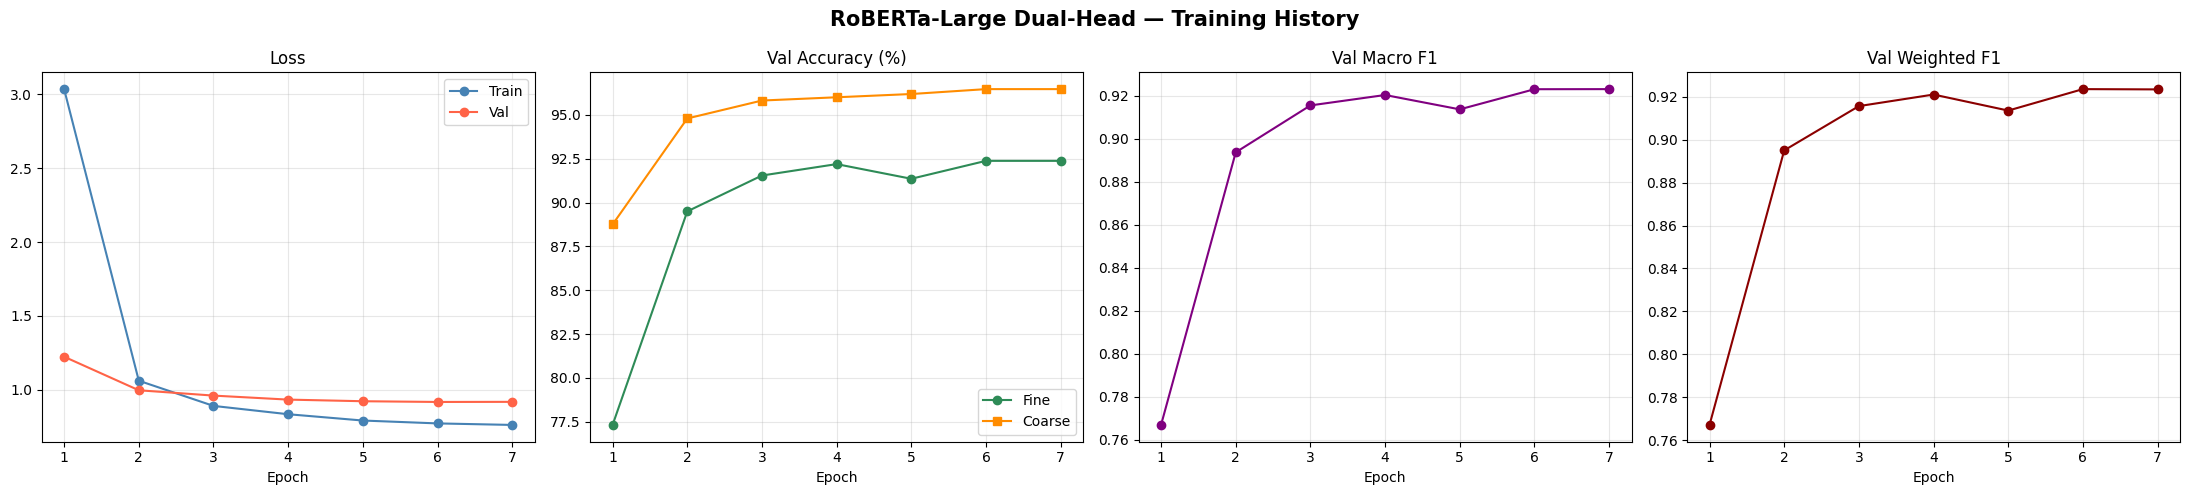

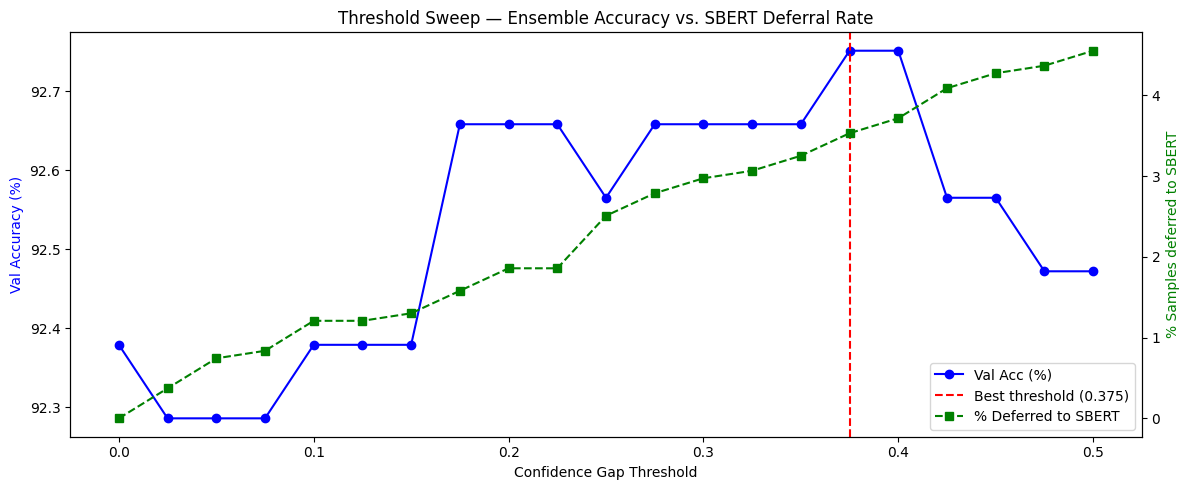

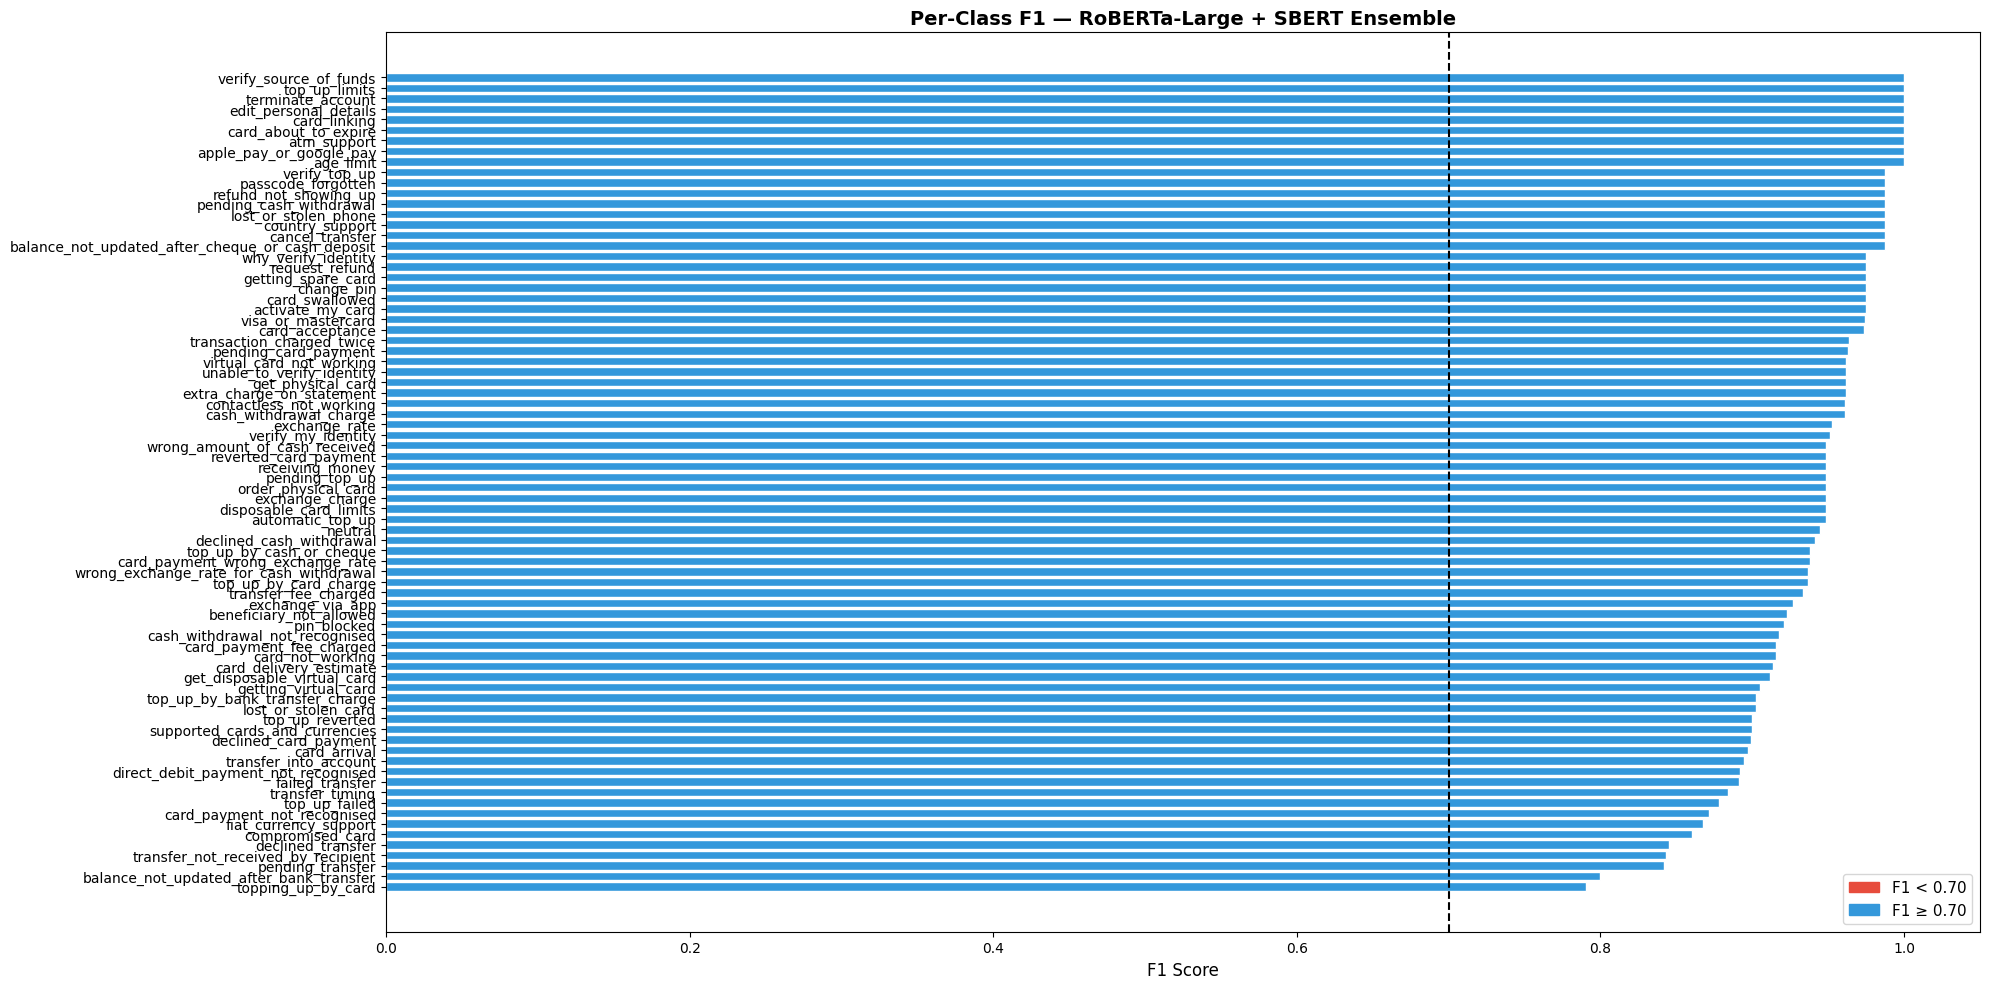

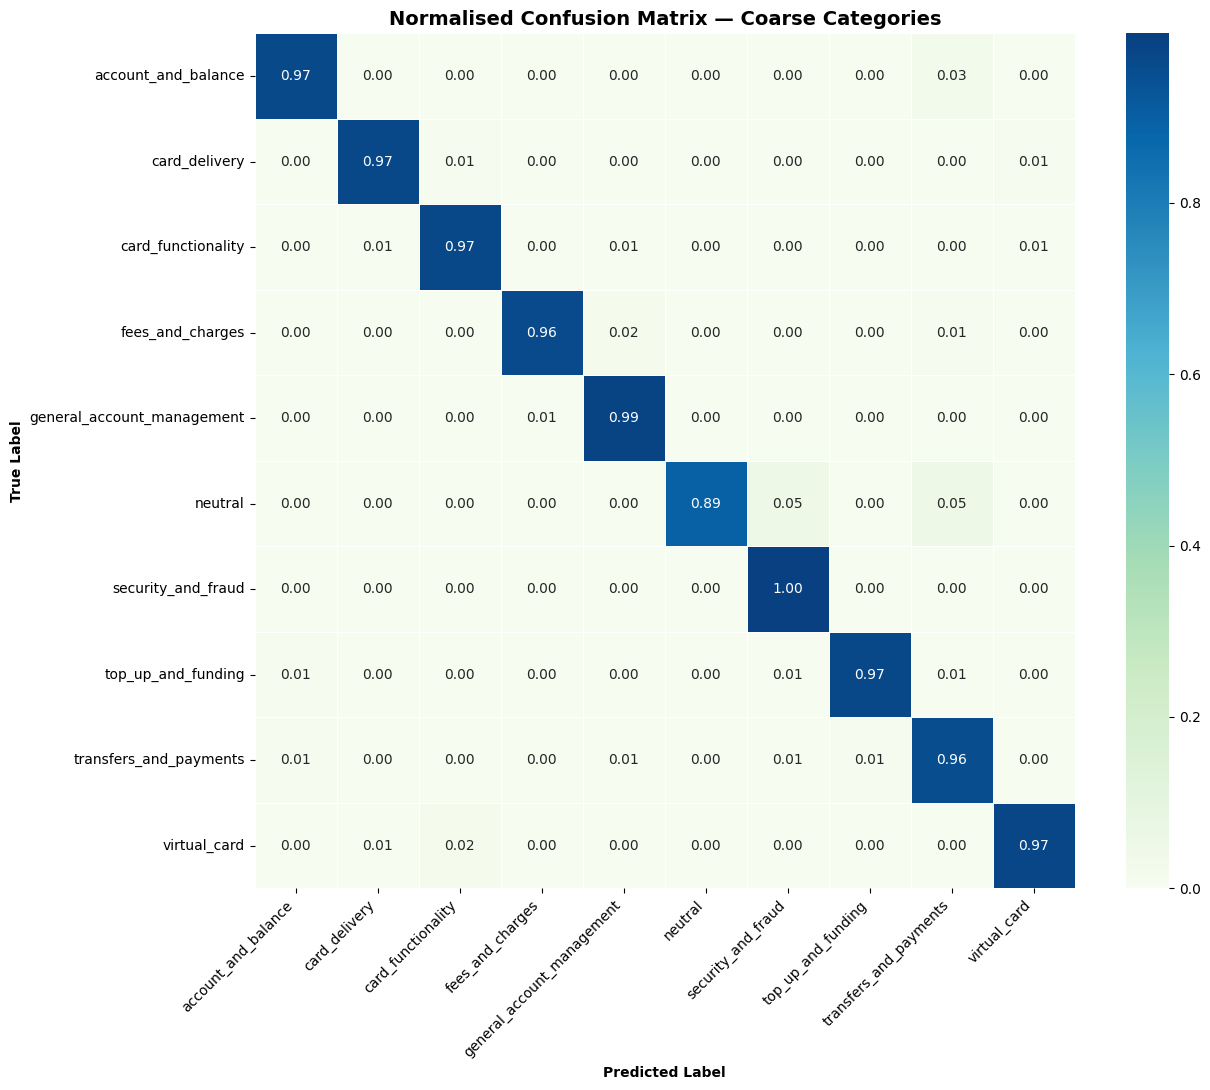

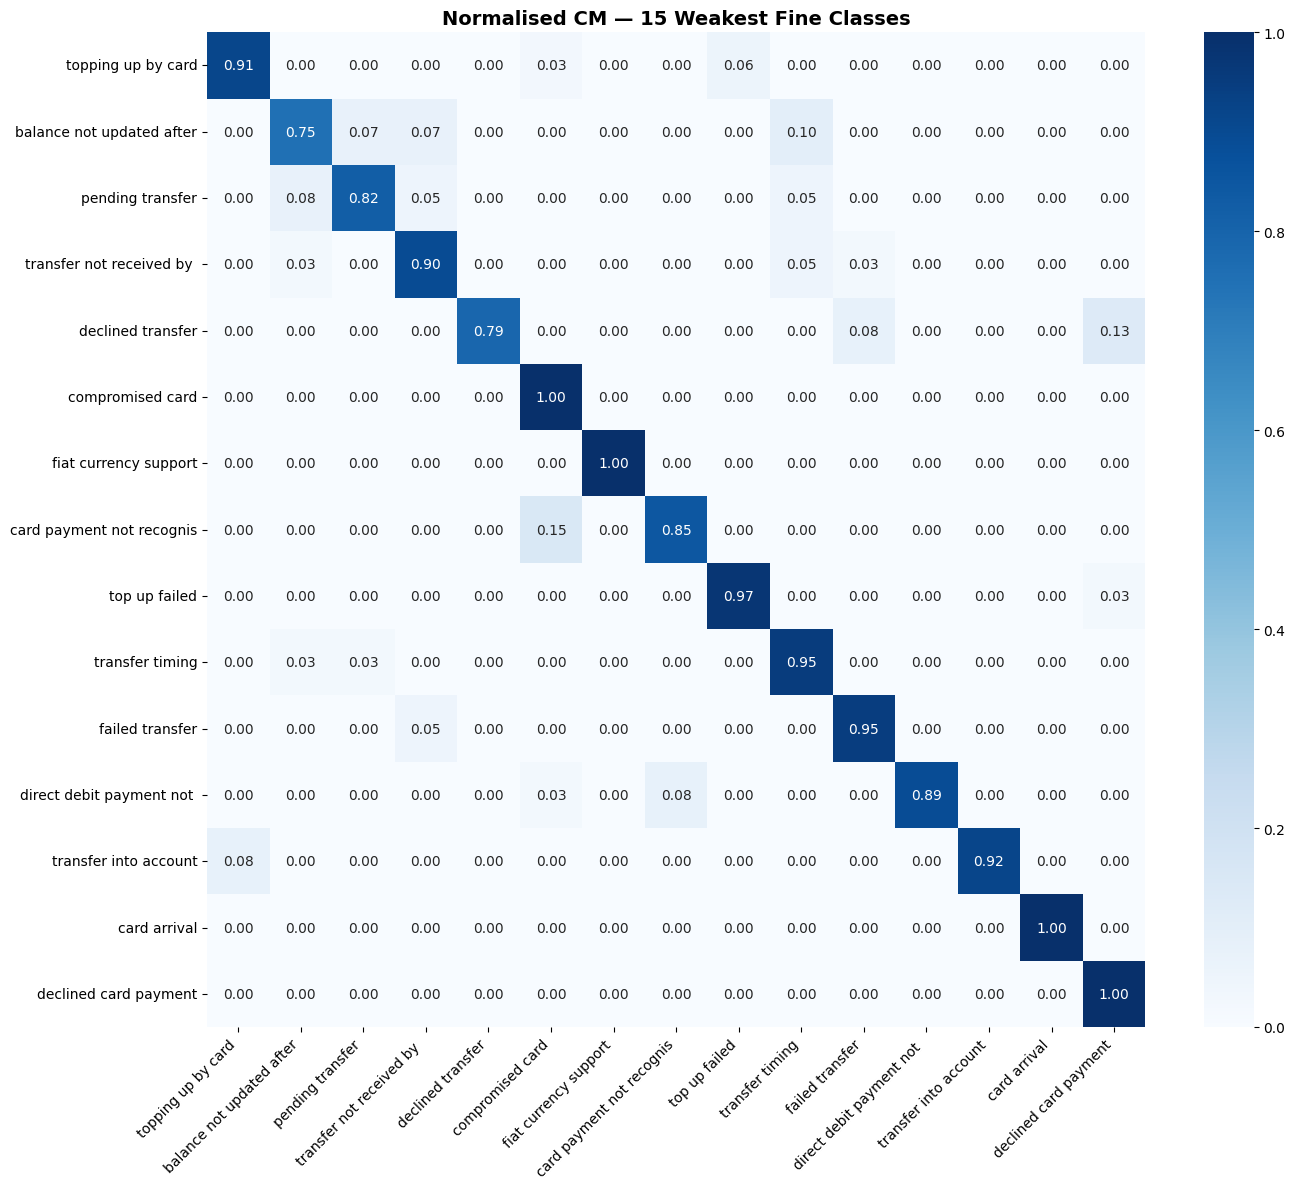

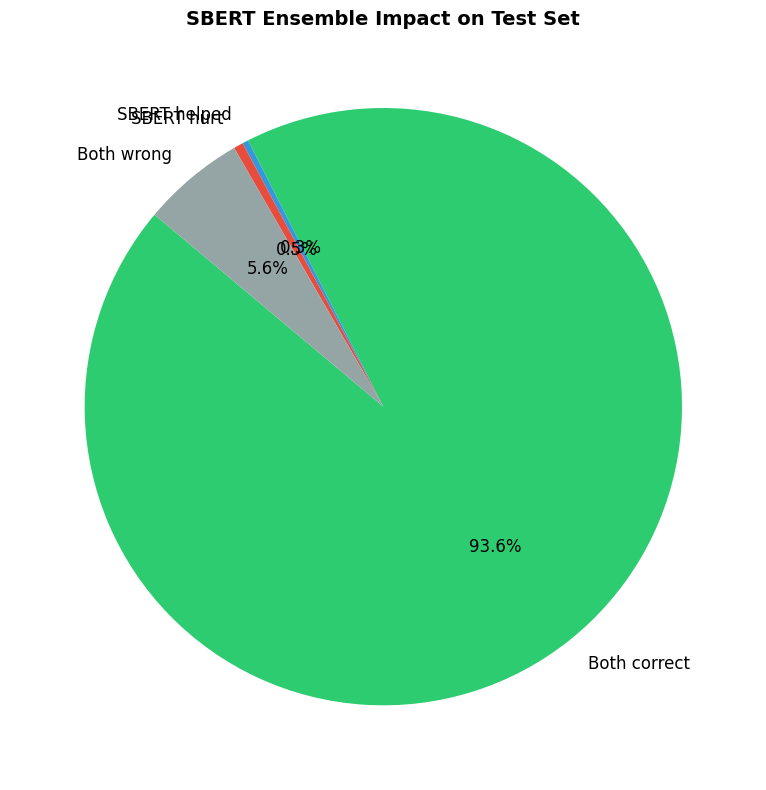

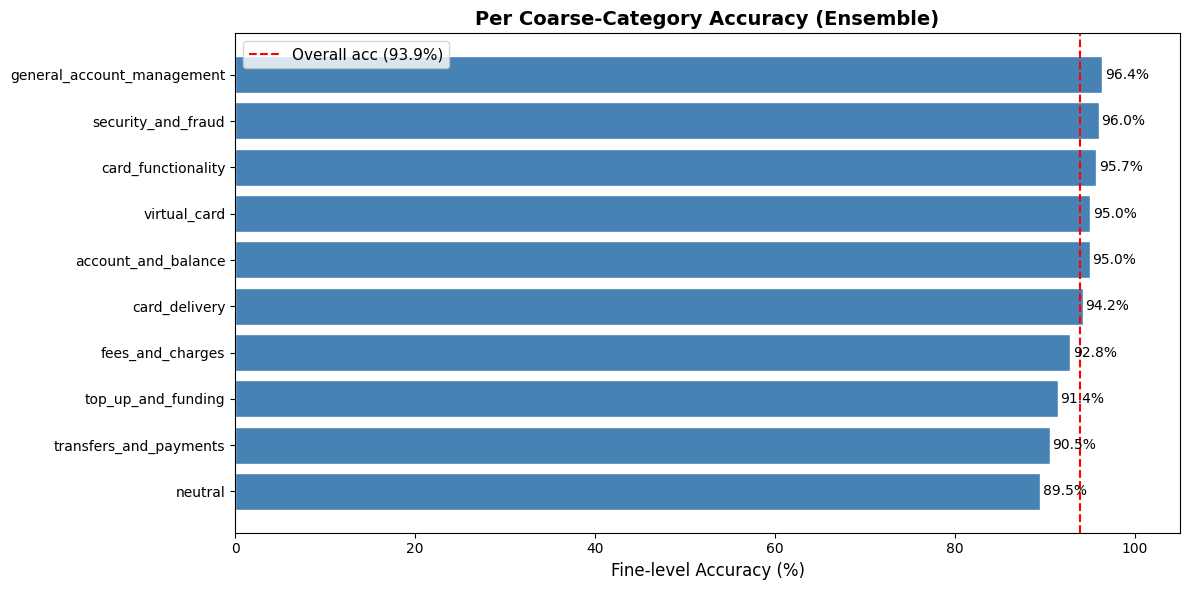

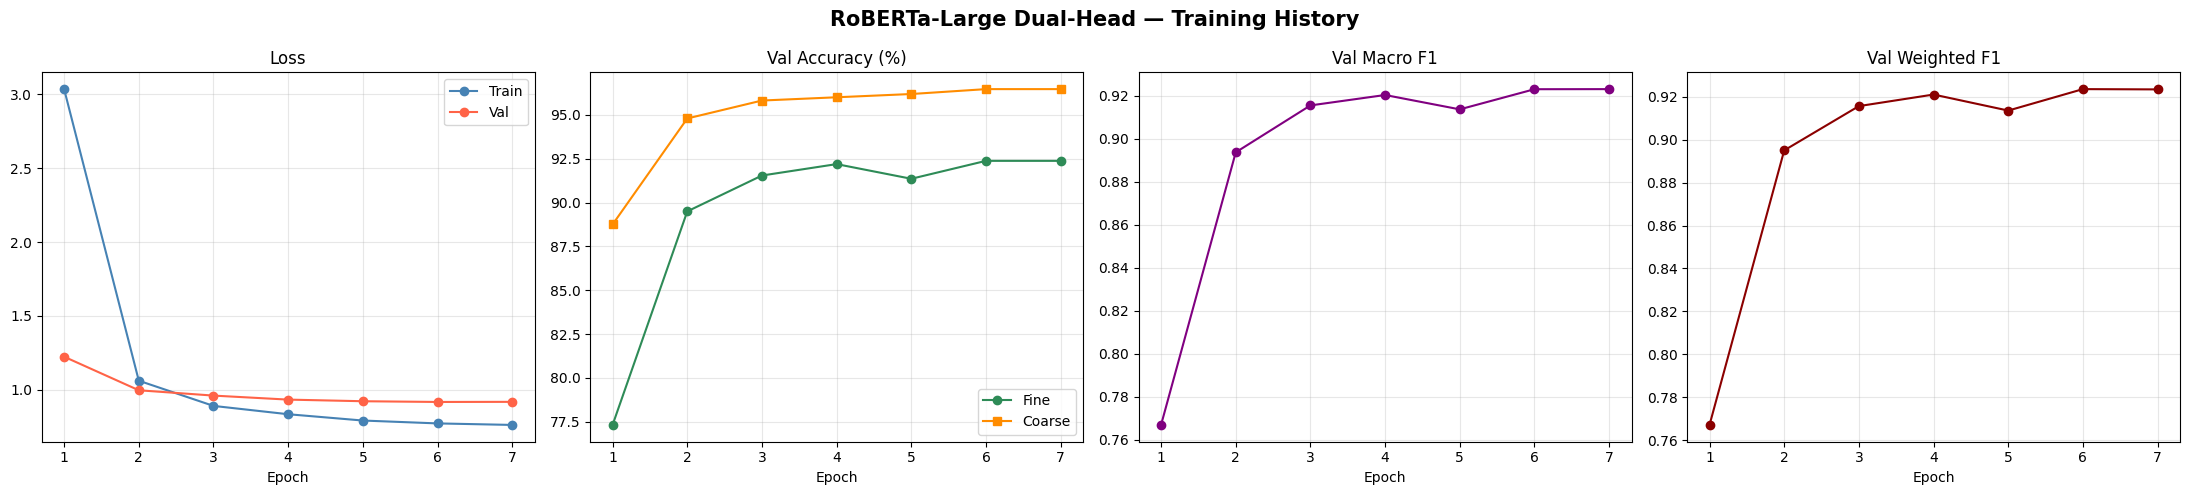

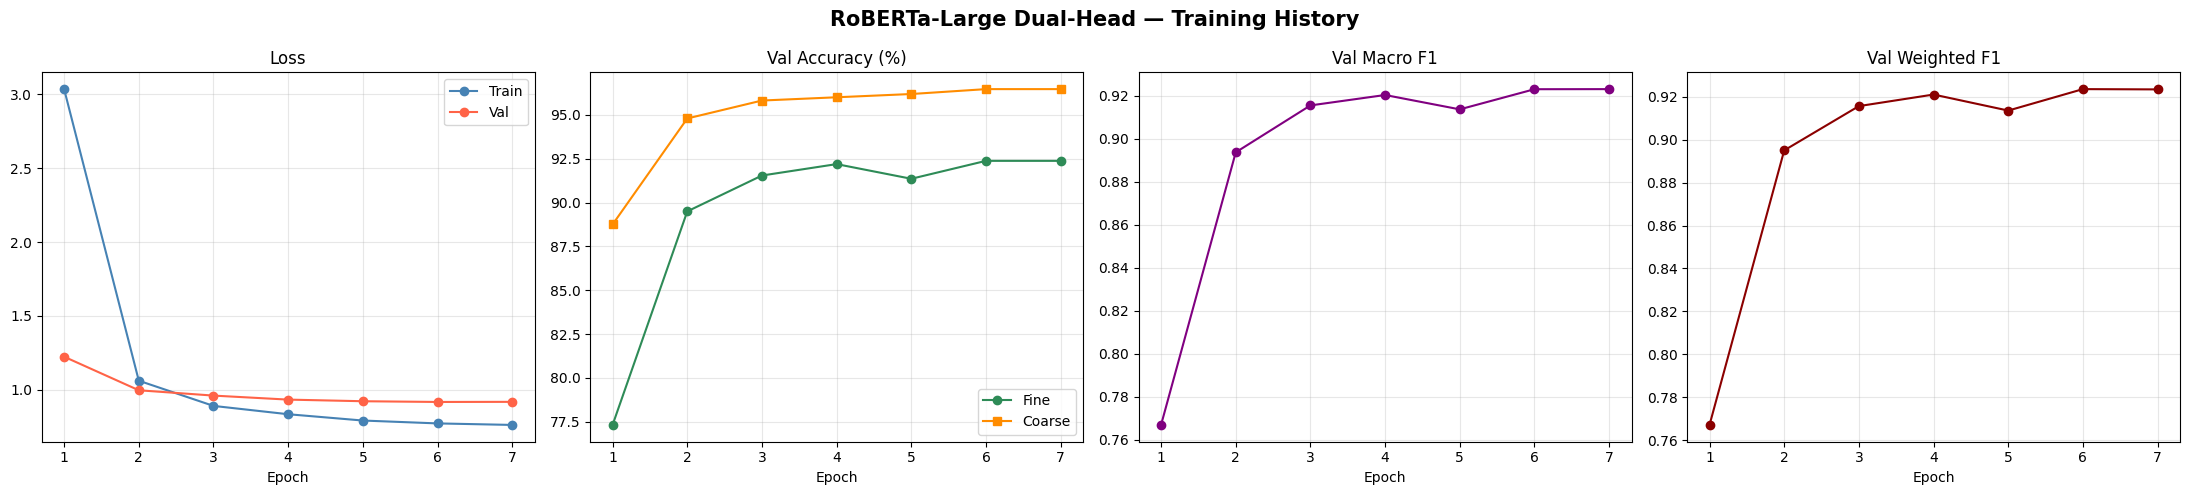

Saved: 01_learning_curves.png


In [22]:
%matplotlib inline
epochs_x = range(1, epochs_ran + 1)

fig, axes = plt.subplots(1, 4, figsize=(22, 5))
fig.suptitle('RoBERTa-Large Dual-Head — Training History', fontsize=15, fontweight='bold')

axes[0].plot(epochs_x, history['train_loss'], label='Train', marker='o', color='steelblue')
axes[0].plot(epochs_x, history['val_loss'],   label='Val',   marker='o', color='tomato')
axes[0].set_title('Loss'); axes[0].set_xlabel('Epoch'); axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(epochs_x, [v*100 for v in history['val_fine_acc']],   marker='o', color='seagreen', label='Fine')
axes[1].plot(epochs_x, [v*100 for v in history['val_coarse_acc']], marker='s', color='darkorange', label='Coarse')
axes[1].set_title('Val Accuracy (%)'); axes[1].set_xlabel('Epoch'); axes[1].legend(); axes[1].grid(alpha=0.3)

axes[2].plot(epochs_x, history['val_macro_f1'], marker='o', color='purple')
axes[2].set_title('Val Macro F1'); axes[2].set_xlabel('Epoch'); axes[2].grid(alpha=0.3)

axes[3].plot(epochs_x, history['val_weighted_f1'], marker='o', color='darkred')
axes[3].set_title('Val Weighted F1'); axes[3].set_xlabel('Epoch'); axes[3].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(f'{PLOTS_DIR}/01_learning_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: 01_learning_curves.png')

## 10. SBERT — Compute Class Centroids

In [11]:
print(f'Loading SBERT: {SBERT_MODEL_NAME}')
sbert_model = SentenceTransformer(SBERT_MODEL_NAME)
sbert_model.eval()

print('Encoding training texts with SBERT...')
train_embeddings = sbert_model.encode(
    train_df['text'].tolist(),
    batch_size=64,
    show_progress_bar=True,
    convert_to_numpy=True,
    normalize_embeddings=True
)
print(f'Embedding matrix shape: {train_embeddings.shape}')

embedding_dim    = train_embeddings.shape[1]
centroid_matrix  = np.zeros((NUM_FINE, embedding_dim), dtype=np.float32)

for class_id in range(NUM_FINE):
    idx = np.where(train_df['fine_label'].values == class_id)[0]
    if len(idx) > 0:
        centroid_matrix[class_id] = train_embeddings[idx].mean(axis=0)
    norm = np.linalg.norm(centroid_matrix[class_id])
    if norm > 0:
        centroid_matrix[class_id] /= norm

np.save(f'{OUTPUT_DIR}/sbert_centroids.npy', centroid_matrix)
print(f'Centroid matrix saved: {centroid_matrix.shape}')

Loading SBERT: all-mpnet-base-v2


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Encoding training texts with SBERT...


Batches:   0%|          | 0/152 [00:00<?, ?it/s]

Embedding matrix shape: (9684, 768)
Centroid matrix saved: (78, 768)


## 11. Confidence Threshold Tuning on Val Set

Val inference:   0%|          | 0/135 [00:00<?, ?it/s]

Encoding val texts with SBERT...


Batches:   0%|          | 0/17 [00:00<?, ?it/s]


Best threshold : 0.375
Val accuracy   : 92.75%
Samples deferred to SBERT: 38 (3.5%)


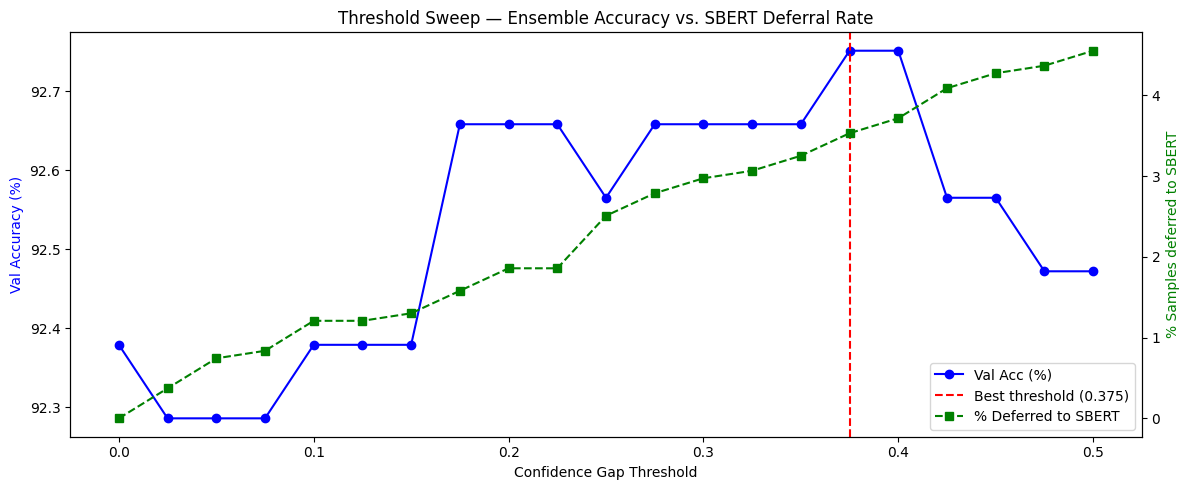

Saved: 02_threshold_sweep.png


In [23]:
# Load best checkpoint
m = model.module if hasattr(model, 'module') else model
m.load_state_dict(torch.load(f'{OUTPUT_DIR}/best_roberta.pt'))
m.eval()

# Collect val predictions + probabilities
print('Collecting val set predictions...')
val_fine_probs_list, val_fine_labels_list = [], []
val_texts_list = val_df['text'].tolist()

with torch.no_grad():
    for batch in tqdm(val_loader, desc='Val inference'):
        ids  = batch['input_ids'].to(DEVICE)
        mask = batch['attention_mask'].to(DEVICE)
        fl   = batch['fine_label']

        coarse_logits, fine_logits = m(ids, mask)
        coarse_preds = coarse_logits.argmax(dim=-1).cpu().numpy()

        masked_fine = fine_logits.clone()
        for i, cp in enumerate(coarse_preds):
            valid    = coarse_to_fine_ids[int(cp)]
            mask_vec = torch.full((fine_logits.size(1),), float('-inf'), device=DEVICE)
            mask_vec[valid] = 0.0
            masked_fine[i] += mask_vec

        probs = F.softmax(masked_fine, dim=-1).cpu().numpy()
        val_fine_probs_list.append(probs)
        val_fine_labels_list.extend(fl.numpy())

val_probs  = np.vstack(val_fine_probs_list)
val_labels = np.array(val_fine_labels_list)

print('Encoding val texts with SBERT...')
val_sbert_embs = sbert_model.encode(
    val_texts_list, batch_size=64,
    show_progress_bar=True, convert_to_numpy=True, normalize_embeddings=True
)

def ensemble_predict(probs, sbert_embs, centroids, threshold, top_k=SBERT_TOP_K):
    sorted_idx = np.argsort(probs, axis=-1)[:, ::-1]
    top1_prob  = probs[np.arange(len(probs)), sorted_idx[:, 0]]
    top2_prob  = probs[np.arange(len(probs)), sorted_idx[:, 1]]
    gap        = top1_prob - top2_prob
    final_preds = sorted_idx[:, 0].copy()
    uncertain_idx = np.where(gap < threshold)[0]
    if len(uncertain_idx) > 0:
        for i in uncertain_idx:
            candidates     = sorted_idx[i, :top_k]
            cand_centroids = centroids[candidates]
            sims           = cand_centroids @ sbert_embs[i]
            best           = candidates[sims.argmax()]
            final_preds[i] = best
    return final_preds

# Sweep thresholds
thresholds = np.arange(0.0, 0.51, 0.025)
results    = []
for thresh in thresholds:
    preds = ensemble_predict(val_probs, val_sbert_embs, centroid_matrix, thresh)
    acc   = accuracy_score(val_labels, preds)
    mf1   = f1_score(val_labels, preds, average='macro', zero_division=0)
    gap_arr     = np.sort(val_probs, axis=-1)[:, ::-1]
    n_deferred  = int(((gap_arr[:, 0] - gap_arr[:, 1]) < thresh).sum())
    results.append({'threshold': thresh, 'val_acc': acc, 'val_macro_f1': mf1,
                    'n_deferred': n_deferred, 'pct_deferred': n_deferred / len(val_labels)})

results_df   = pd.DataFrame(results)
best_row     = results_df.loc[results_df['val_acc'].idxmax()]
CONF_THRESHOLD = float(best_row['threshold'])

print(f'\nBest threshold : {CONF_THRESHOLD:.3f}')
print(f'Val accuracy   : {best_row["val_acc"]*100:.2f}%')
print(f'Samples deferred to SBERT: {int(best_row["n_deferred"])} ({best_row["pct_deferred"]*100:.1f}%)')

# Plot
fig, ax1 = plt.subplots(figsize=(12, 5))
ax1.plot(results_df['threshold'], results_df['val_acc'] * 100, 'b-o', label='Val Acc (%)')
ax1.set_xlabel('Confidence Gap Threshold')
ax1.set_ylabel('Val Accuracy (%)', color='b')
ax1.axvline(CONF_THRESHOLD, color='red', linestyle='--', label=f'Best threshold ({CONF_THRESHOLD:.3f})')
ax2 = ax1.twinx()
ax2.plot(results_df['threshold'], results_df['pct_deferred'] * 100, 'g--s', label='% Deferred to SBERT')
ax2.set_ylabel('% Samples deferred to SBERT', color='g')
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='lower right')
plt.title('Threshold Sweep — Ensemble Accuracy vs. SBERT Deferral Rate')
plt.tight_layout()
plt.savefig(f'{PLOTS_DIR}/02_threshold_sweep.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: 02_threshold_sweep.png')

## 12. Final Test Evaluation — RoBERTa Only vs. Ensemble

In [24]:
print('='*60)
print('FINAL TEST EVALUATION')
print('='*60)

test_fine_probs_list, test_labels_list = [], []
test_texts_list = test_df['text'].tolist()

with torch.no_grad():
    for batch in tqdm(test_loader, desc='Test inference (RoBERTa)'):
        ids  = batch['input_ids'].to(DEVICE)
        mask = batch['attention_mask'].to(DEVICE)
        fl   = batch['fine_label']

        coarse_logits, fine_logits = m(ids, mask)
        coarse_preds = coarse_logits.argmax(dim=-1).cpu().numpy()

        masked_fine = fine_logits.clone()
        for i, cp in enumerate(coarse_preds):
            valid    = coarse_to_fine_ids[int(cp)]
            mask_vec = torch.full((fine_logits.size(1),), float('-inf'), device=DEVICE)
            mask_vec[valid] = 0.0
            masked_fine[i] += mask_vec

        probs = F.softmax(masked_fine, dim=-1).cpu().numpy()
        test_fine_probs_list.append(probs)
        test_labels_list.extend(fl.numpy())

test_probs  = np.vstack(test_fine_probs_list)
test_labels = np.array(test_labels_list)

roberta_preds = test_probs.argmax(axis=-1)
roberta_acc   = accuracy_score(test_labels, roberta_preds)
roberta_wf1   = f1_score(test_labels, roberta_preds, average='weighted', zero_division=0)
roberta_mf1   = f1_score(test_labels, roberta_preds, average='macro',    zero_division=0)

print(f'\n[RoBERTa-Large Only]')
print(f'  Fine Accuracy : {roberta_acc*100:.2f}%')
print(f'  Weighted F1   : {roberta_wf1:.4f}')
print(f'  Macro F1      : {roberta_mf1:.4f}')

print('\nEncoding test texts with SBERT...')
test_sbert_embs = sbert_model.encode(
    test_texts_list, batch_size=64,
    show_progress_bar=True, convert_to_numpy=True, normalize_embeddings=True)

ensemble_preds = ensemble_predict(test_probs, test_sbert_embs, centroid_matrix, CONF_THRESHOLD)
ensemble_acc   = accuracy_score(test_labels, ensemble_preds)
ensemble_wf1   = f1_score(test_labels, ensemble_preds, average='weighted', zero_division=0)
ensemble_mf1   = f1_score(test_labels, ensemble_preds, average='macro',    zero_division=0)

gap_arr          = np.sort(test_probs, axis=-1)[:, ::-1]
n_deferred_test  = int(((gap_arr[:, 0] - gap_arr[:, 1]) < CONF_THRESHOLD).sum())

print(f'\n[RoBERTa-Large + SBERT Ensemble  (threshold={CONF_THRESHOLD:.3f})]')
print(f'  Fine Accuracy : {ensemble_acc*100:.2f}%')
print(f'  Weighted F1   : {ensemble_wf1:.4f}')
print(f'  Macro F1      : {ensemble_mf1:.4f}')
print(f'  Deferred      : {n_deferred_test} / {len(test_labels)} ({n_deferred_test/len(test_labels)*100:.1f}%)')

print('\n' + '='*60)
print(f'  Accuracy gain : {(ensemble_acc - roberta_acc)*100:+.2f}%')
print(f'  Macro F1 gain : {(ensemble_mf1 - roberta_mf1):+.4f}')
print('='*60)

FINAL TEST EVALUATION


Test inference (RoBERTa):   0%|          | 0/387 [00:00<?, ?it/s]


[RoBERTa-Large Only]
  Fine Accuracy : 94.11%
  Weighted F1   : 0.9411
  Macro F1      : 0.9411

Encoding test texts with SBERT...


Batches:   0%|          | 0/49 [00:00<?, ?it/s]


[RoBERTa-Large + SBERT Ensemble  (threshold=0.375)]
  Fine Accuracy : 93.92%
  Weighted F1   : 0.9393
  Macro F1      : 0.9393
  Deferred      : 87 / 3092 (2.8%)

  Accuracy gain : -0.19%
  Macro F1 gain : -0.0018


## 13. Classification Report & Per-Class F1

                                                  precision    recall  f1-score   support

                                activate_my_card      0.975     0.975     0.975        40
                                       age_limit      1.000     1.000     1.000        40
                         apple_pay_or_google_pay      1.000     1.000     1.000        40
                                     atm_support      1.000     1.000     1.000        39
                                automatic_top_up      0.974     0.925     0.949        40
         balance_not_updated_after_bank_transfer      0.857     0.750     0.800        40
balance_not_updated_after_cheque_or_cash_deposit      1.000     0.975     0.987        40
                         beneficiary_not_allowed      0.947     0.900     0.923        40
                                 cancel_transfer      1.000     0.975     0.987        40
                            card_about_to_expire      1.000     1.000     1.000        40
         

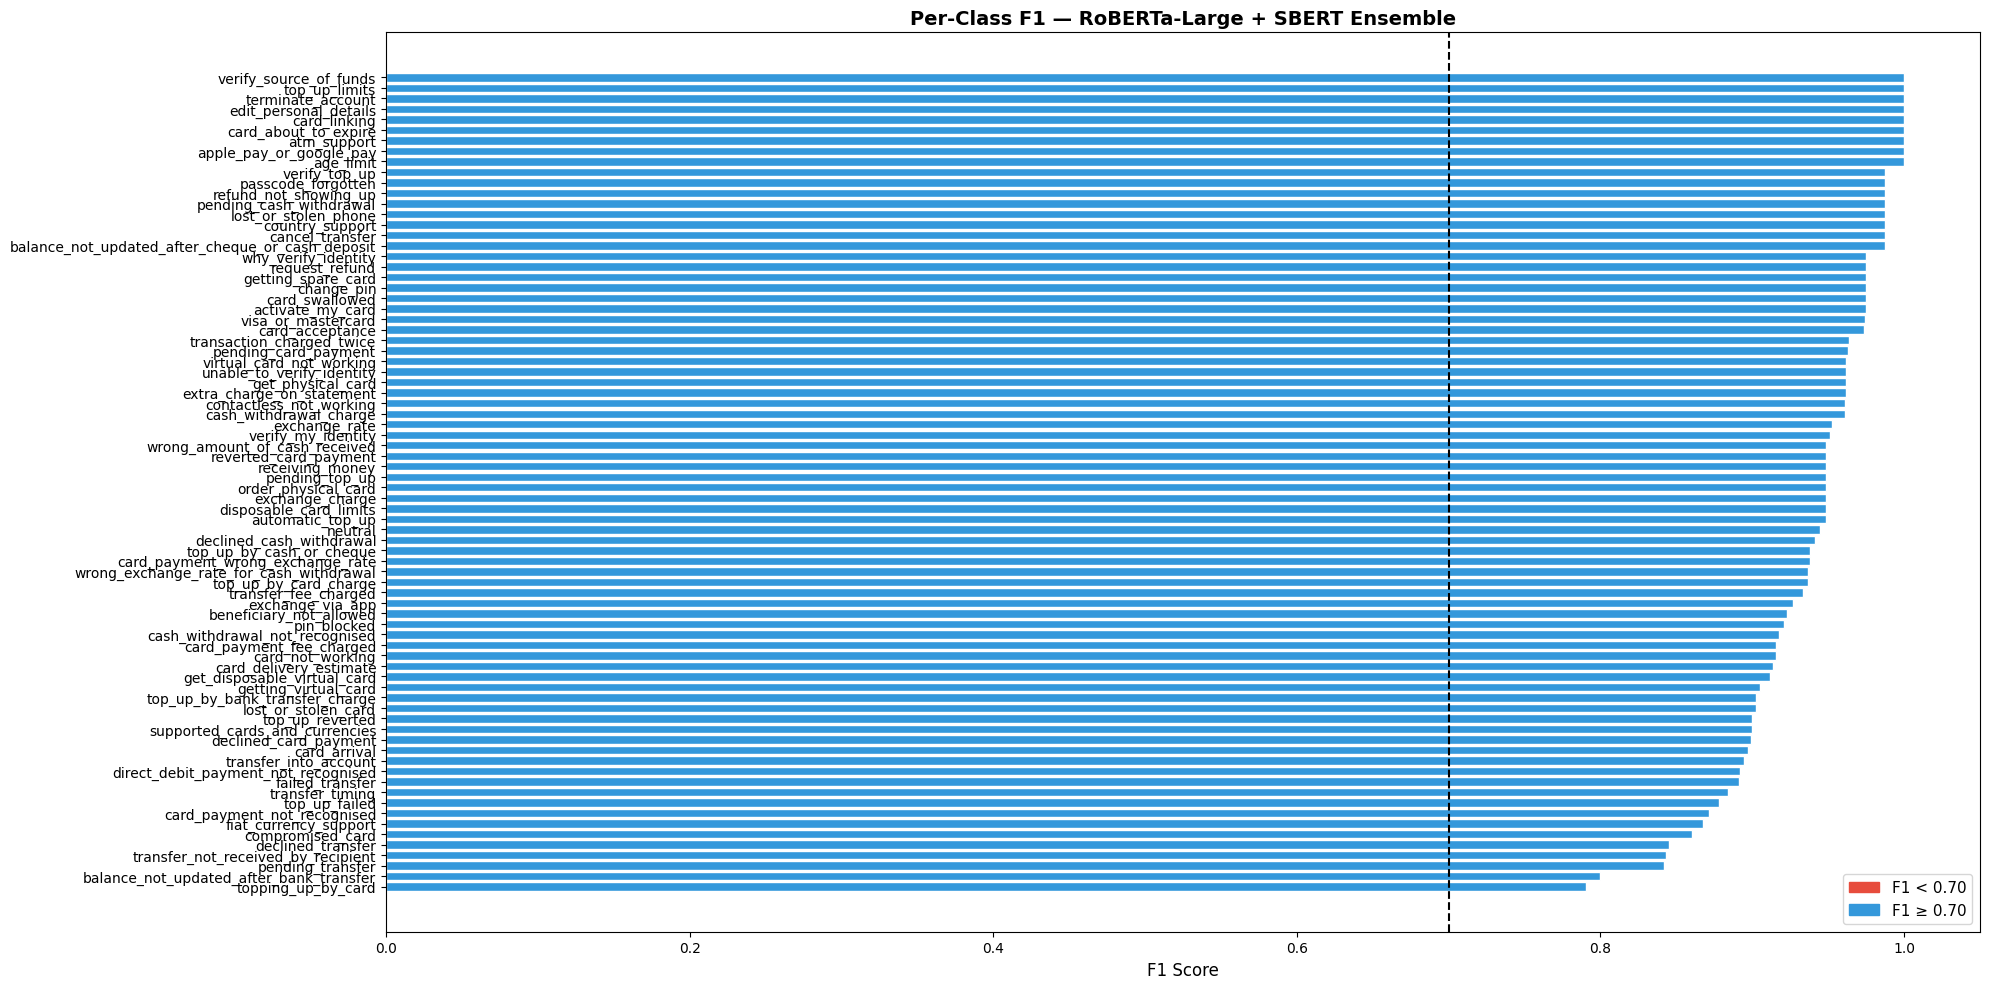

Saved: 03_per_class_f1.png

Classes with F1 < 0.70: 0


In [25]:
report = classification_report(
    test_labels, ensemble_preds,
    target_names=fine_le.classes_, digits=3
)
print(report)
with open(f'{OUTPUT_DIR}/classification_report.txt', 'w') as f:
    f.write(report)

report_dict = classification_report(
    test_labels, ensemble_preds,
    target_names=fine_le.classes_, output_dict=True
)
class_f1 = {k: v['f1-score']
             for k, v in report_dict.items()
             if k not in ('accuracy', 'macro avg', 'weighted avg')}
class_f1_sorted = dict(sorted(class_f1.items(), key=lambda x: x[1]))

# Per-class F1 bar chart
fig, ax = plt.subplots(figsize=(20, 10))
colors   = ['#e74c3c' if v < 0.70 else '#3498db' for v in class_f1_sorted.values()]
ax.barh(list(class_f1_sorted.keys()), list(class_f1_sorted.values()), color=colors, edgecolor='white')
ax.axvline(0.70, color='black', linestyle='--', lw=1.5, label='0.70 threshold')
ax.set_xlabel('F1 Score', fontsize=12)
ax.set_title('Per-Class F1 — RoBERTa-Large + SBERT Ensemble', fontsize=14, fontweight='bold')
ax.legend(fontsize=11)
red_patch  = mpatches.Patch(color='#e74c3c', label='F1 < 0.70')
blue_patch = mpatches.Patch(color='#3498db', label='F1 ≥ 0.70')
ax.legend(handles=[red_patch, blue_patch], fontsize=11)
plt.tight_layout()
plt.savefig(f'{PLOTS_DIR}/03_per_class_f1.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: 03_per_class_f1.png')

weak = {k: v for k, v in class_f1_sorted.items() if v < 0.70}
print(f'\nClasses with F1 < 0.70: {len(weak)}')
for k, v in weak.items():
    print(f'  {k:<55} F1 = {v:.3f}')

## 14. Confusion Matrices

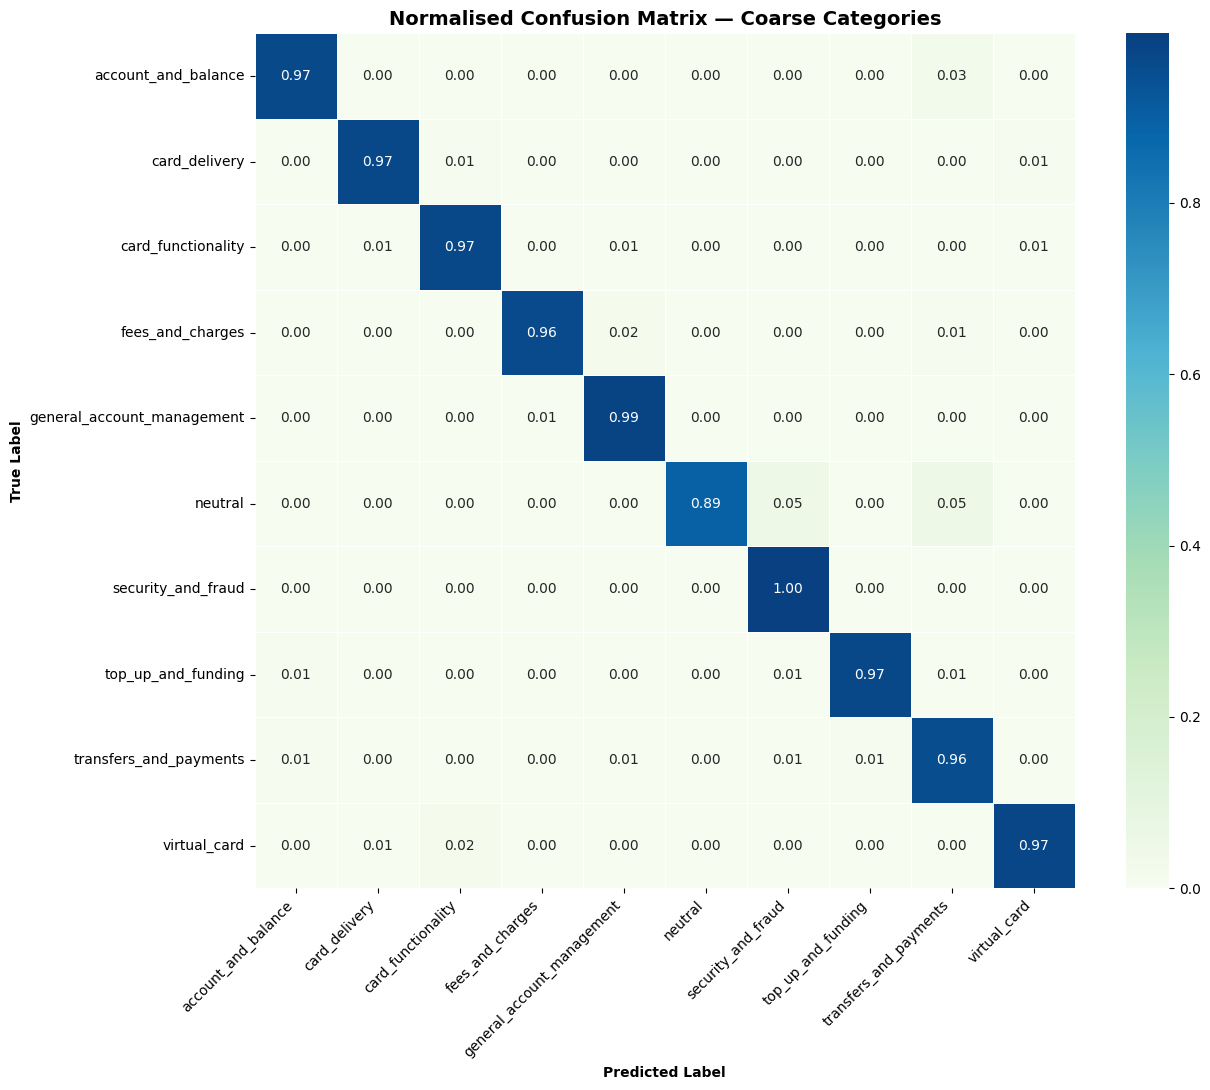

Saved: 04_confusion_matrix_coarse.png


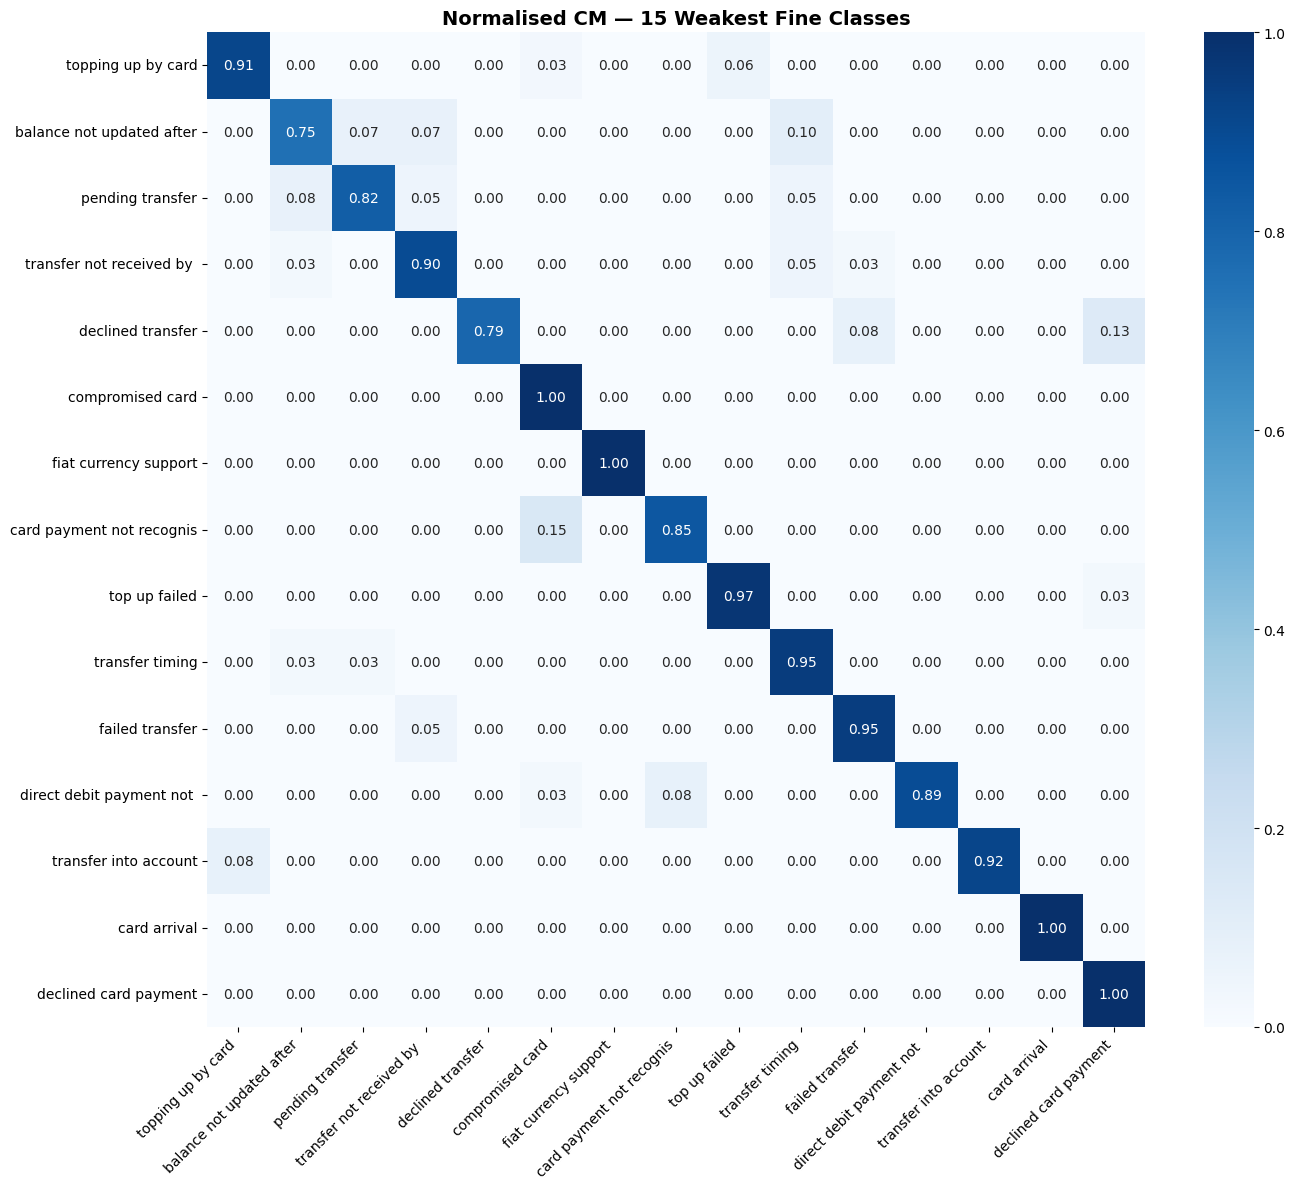

Saved: 05_confusion_matrix_weak_fine.png


In [26]:
# ── Coarse confusion matrix ────────────────────────────────────────────────────
fine_to_coarse = {}
for v, c in id2fine.items():
    coarse_name = coarse_mapping.get(c, 'neutral')
    coarse_id   = coarse_le.transform([coarse_name])[0]
    fine_to_coarse[v] = coarse_id

ensemble_coarse_preds = np.array([fine_to_coarse[p] for p in ensemble_preds])
test_coarse_labels    = test_df['coarse_label'].values

cm_coarse = confusion_matrix(test_coarse_labels, ensemble_coarse_preds, normalize='true')
fig, ax = plt.subplots(figsize=(13, 11))
sns.heatmap(cm_coarse, annot=True, fmt='.2f', cmap='GnBu',
            xticklabels=coarse_le.classes_, yticklabels=coarse_le.classes_,
            linewidths=.5, ax=ax)
ax.set_title('Normalised Confusion Matrix — Coarse Categories', fontsize=14, fontweight='bold')
ax.set_ylabel('True Label', fontweight='bold')
ax.set_xlabel('Predicted Label', fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig(f'{PLOTS_DIR}/04_confusion_matrix_coarse.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: 04_confusion_matrix_coarse.png')

# ── Weak-class fine confusion matrix (15 weakest classes) ─────────────────────
cm_fine    = confusion_matrix(test_labels, ensemble_preds)
weak_names = list(class_f1_sorted.keys())[:15]
weak_ids   = [int(np.where(fine_le.classes_ == n)[0][0]) for n in weak_names]
cm_weak    = cm_fine[np.ix_(weak_ids, weak_ids)].astype(float)
cm_weak   /= np.maximum(cm_weak.sum(axis=1, keepdims=True), 1)

short = [n.replace('_', ' ')[:25] for n in weak_names]
fig, ax = plt.subplots(figsize=(14, 12))
sns.heatmap(cm_weak, annot=True, fmt='.2f', cmap='Blues',
            xticklabels=short, yticklabels=short, ax=ax)
ax.set_title('Normalised CM — 15 Weakest Fine Classes', fontsize=14, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig(f'{PLOTS_DIR}/05_confusion_matrix_weak_fine.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: 05_confusion_matrix_weak_fine.png')

## 15. Error Analysis

Total test samples  : 3,092
RoBERTa correct     : 2,910 (94.11%)
Ensemble correct    : 2,904 (93.92%)
SBERT fixed (helped): 10
SBERT broke (hurt)  : 16

── Samples SBERT fixed (first 5) ──
  Text    : Why is my debit card being declined when I have money?
  True    : declined_card_payment
  RoBERTa : reverted_card_payment  →  Ensemble: declined_card_payment

  Text    : Says my transfer can't be completed?
  True    : failed_transfer
  RoBERTa : beneficiary_not_allowed  →  Ensemble: failed_transfer

  Text    : My transfer hasn't gone through yet.
  True    : pending_transfer
  RoBERTa : failed_transfer  →  Ensemble: pending_transfer

  Text    : Will a transfer incur a fee?
  True    : top_up_by_bank_transfer_charge
  RoBERTa : transfer_fee_charged  →  Ensemble: top_up_by_bank_transfer_charge

  Text    : Why hasn't my transfer gone through yet?
  True    : pending_transfer
  RoBERTa : transfer_not_received_by_recipient  →  Ensemble: pending_transfer

Error file saved: 188 misclassifi

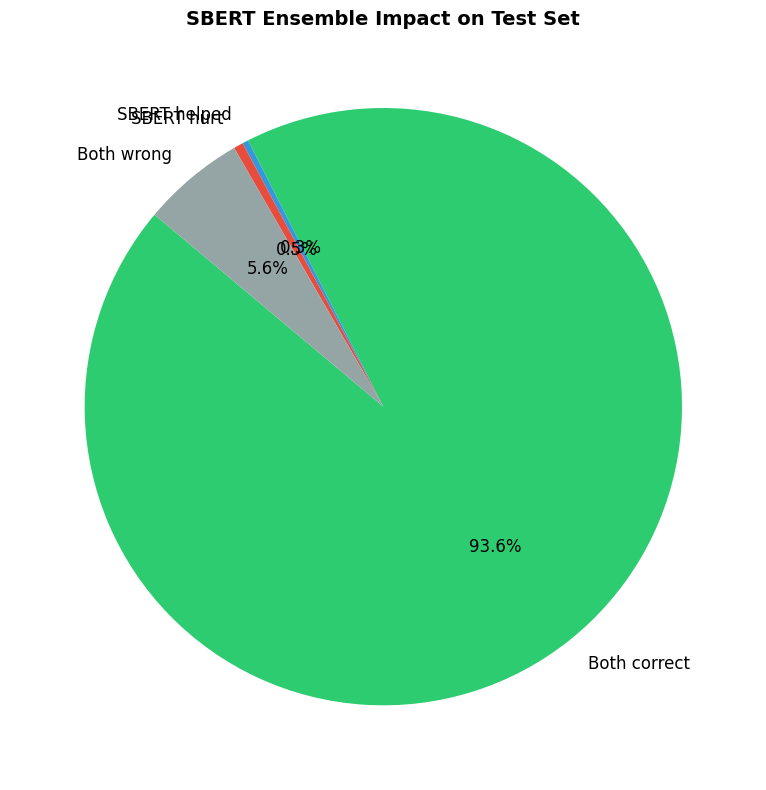

Saved: 06_sbert_impact_pie.png


In [27]:
results_df_out = test_df[['text', 'category', 'coarse_category']].copy()
results_df_out['roberta_pred']     = [fine_le.classes_[p] for p in roberta_preds]
results_df_out['ensemble_pred']    = [fine_le.classes_[p] for p in ensemble_preds]
results_df_out['roberta_correct']  = results_df_out['category'] == results_df_out['roberta_pred']
results_df_out['ensemble_correct'] = results_df_out['category'] == results_df_out['ensemble_pred']
results_df_out['sbert_helped']     = (~results_df_out['roberta_correct']) & results_df_out['ensemble_correct']
results_df_out['sbert_hurt']       = results_df_out['roberta_correct'] & (~results_df_out['ensemble_correct'])

print(f'Total test samples  : {len(results_df_out):,}')
print(f'RoBERTa correct     : {results_df_out["roberta_correct"].sum():,} ({results_df_out["roberta_correct"].mean()*100:.2f}%)')
print(f'Ensemble correct    : {results_df_out["ensemble_correct"].sum():,} ({results_df_out["ensemble_correct"].mean()*100:.2f}%)')
print(f'SBERT fixed (helped): {results_df_out["sbert_helped"].sum():,}')
print(f'SBERT broke (hurt)  : {results_df_out["sbert_hurt"].sum():,}')

print('\n── Samples SBERT fixed (first 5) ──')
for _, r in results_df_out[results_df_out['sbert_helped']].head(5).iterrows():
    print(f'  Text    : {r["text"][:80]}')
    print(f'  True    : {r["category"]}')
    print(f'  RoBERTa : {r["roberta_pred"]}  →  Ensemble: {r["ensemble_pred"]}')
    print()

errors_df = results_df_out[~results_df_out['ensemble_correct']].reset_index(drop=True)
errors_df.to_csv(f'{OUTPUT_DIR}/errors.csv', index=False)
print(f'Error file saved: {len(errors_df)} misclassified samples')

# Pie chart — SBERT impact
labels_pie  = ['Both correct', 'SBERT helped', 'SBERT hurt', 'Both wrong']
both_correct = (results_df_out['roberta_correct'] & results_df_out['ensemble_correct']).sum()
both_wrong   = (~results_df_out['roberta_correct'] & ~results_df_out['ensemble_correct']).sum()
sizes        = [both_correct, results_df_out['sbert_helped'].sum(),
                results_df_out['sbert_hurt'].sum(), both_wrong]
colors_pie   = ['#2ecc71','#3498db','#e74c3c','#95a5a6']
fig, ax = plt.subplots(figsize=(8, 8))
ax.pie(sizes, labels=labels_pie, colors=colors_pie, autopct='%1.1f%%', startangle=140, textprops={'fontsize': 12})
ax.set_title('SBERT Ensemble Impact on Test Set', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{PLOTS_DIR}/06_sbert_impact_pie.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: 06_sbert_impact_pie.png')

## 16. Coarse Category Performance Bar Chart

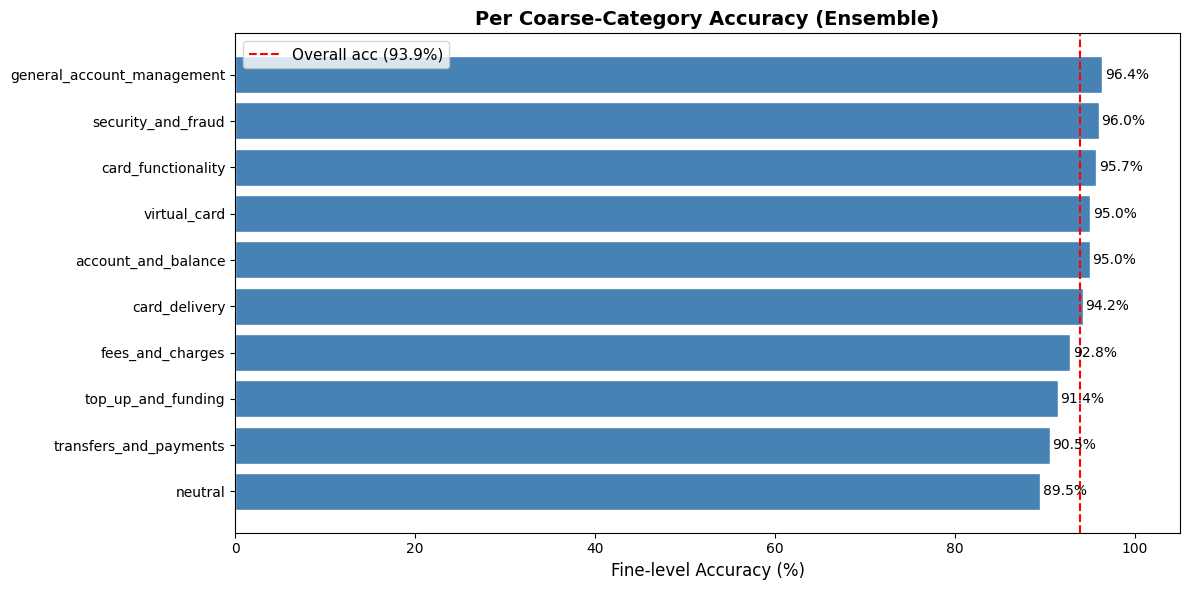

Saved: 07_coarse_category_accuracy.png


In [28]:
coarse_accs = {}
for ci, cname in id2coarse.items():
    mask_c     = test_coarse_labels == ci
    if mask_c.sum() == 0: continue
    coarse_accs[cname] = accuracy_score(test_labels[mask_c], ensemble_preds[mask_c])

coarse_accs_sorted = dict(sorted(coarse_accs.items(), key=lambda x: x[1]))

fig, ax = plt.subplots(figsize=(12, 6))
bars = ax.barh(list(coarse_accs_sorted.keys()),
               [v*100 for v in coarse_accs_sorted.values()],
               color='steelblue', edgecolor='white')
ax.axvline(ensemble_acc*100, color='red', linestyle='--', lw=1.5, label=f'Overall acc ({ensemble_acc*100:.1f}%)')
for bar, val in zip(bars, coarse_accs_sorted.values()):
    ax.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height()/2,
            f'{val*100:.1f}%', va='center', fontsize=10)
ax.set_xlabel('Fine-level Accuracy (%)', fontsize=12)
ax.set_title('Per Coarse-Category Accuracy (Ensemble)', fontsize=14, fontweight='bold')
ax.legend(fontsize=11)
ax.set_xlim(0, 105)
plt.tight_layout()
plt.savefig(f'{PLOTS_DIR}/07_coarse_category_accuracy.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: 07_coarse_category_accuracy.png')

## 17. Save All Artifacts & Final Summary

In [18]:
tokenizer.save_pretrained(f'{OUTPUT_DIR}/tokenizer')

config = {
    'model_name'           : MODEL_NAME,
    'sbert_model_name'     : SBERT_MODEL_NAME,
    'max_len'              : MAX_LEN,
    'batch_size'           : BATCH_SIZE,
    'grad_accum'           : GRAD_ACCUM,
    'effective_batch'      : BATCH_SIZE * GRAD_ACCUM,
    'epochs_ran'           : epochs_ran,
    'label_smoothing'      : LABEL_SMOOTHING,
    'warmup_ratio'         : WARMUP_RATIO,
    'coarse_weight'        : COARSE_WEIGHT,
    'fine_weight'          : FINE_WEIGHT,
    'val_size'             : VAL_SIZE,
    'num_fine_classes'     : NUM_FINE,
    'num_coarse_classes'   : NUM_COARSE,
    'conf_threshold'       : CONF_THRESHOLD,
    'sbert_top_k'          : SBERT_TOP_K,
    'test_roberta_acc'     : round(roberta_acc,   4),
    'test_roberta_wf1'     : round(roberta_wf1,   4),
    'test_roberta_mf1'     : round(roberta_mf1,   4),
    'test_ensemble_acc'    : round(ensemble_acc,  4),
    'test_ensemble_wf1'    : round(ensemble_wf1,  4),
    'test_ensemble_mf1'    : round(ensemble_mf1,  4),
    'n_deferred_to_sbert'  : n_deferred_test,
}
with open(f'{OUTPUT_DIR}/training_config.json', 'w') as f:
    json.dump(config, f, indent=2)

# FIX: Dynamic summary table
print('\n' + '='*65)
print('FINAL RESULTS SUMMARY')
print('='*65)
print(f'{"Metric":<30} {"RoBERTa-Large":>15} {"+ SBERT":>12}')
print('-'*65)
print(f'{"Fine Accuracy":<30} {roberta_acc*100:>14.2f}% {ensemble_acc*100:>11.2f}%')
print(f'{"Weighted F1":<30} {roberta_wf1:>15.4f} {ensemble_wf1:>12.4f}')
print(f'{"Macro F1":<30} {roberta_mf1:>15.4f} {ensemble_mf1:>12.4f}')
print(f'{"Accuracy gain":<30} {"":>15} {(ensemble_acc-roberta_acc)*100:>+11.2f}%')
print(f'{"Macro F1 gain":<30} {"":>15} {(ensemble_mf1-roberta_mf1):>+12.4f}')
print(f'{"Samples deferred to SBERT":<30} {"":>15} {n_deferred_test:>10} ({n_deferred_test/len(test_labels)*100:.1f}%)')
print('='*65)
print(json.dumps(config, indent=2))


FINAL RESULTS SUMMARY
Metric                           RoBERTa-Large      + SBERT
-----------------------------------------------------------------
Fine Accuracy                           94.11%       93.92%
Weighted F1                             0.9411       0.9393
Macro F1                                0.9411       0.9393
Accuracy gain                                        -0.19%
Macro F1 gain                                       -0.0018
Samples deferred to SBERT                              87 (2.8%)
{
  "model_name": "roberta-large",
  "sbert_model_name": "all-mpnet-base-v2",
  "max_len": 128,
  "batch_size": 8,
  "grad_accum": 4,
  "effective_batch": 32,
  "epochs_ran": 7,
  "label_smoothing": 0.1,
  "warmup_ratio": 0.1,
  "coarse_weight": 0.3,
  "fine_weight": 0.7,
  "val_size": 0.1,
  "num_fine_classes": 78,
  "num_coarse_classes": 10,
  "conf_threshold": 0.375,
  "sbert_top_k": 5,
  "test_roberta_acc": 0.9411,
  "test_roberta_wf1": 0.9411,
  "test_roberta_mf1": 0.9411,
  "

## 18. Download Everything — Models + Plots

In [20]:
# ── Zip 1: Full model artifacts (for HuggingFace upload) ──────────────────────
MODEL_ZIP = '/kaggle/working/MODEL_roberta_large_banking77'
shutil.make_archive(MODEL_ZIP, 'zip', OUTPUT_DIR)
print(f'Model zip : {MODEL_ZIP}.zip')

# ── Zip 2: Plots only (for presentation) ─────────────────────────────────────
PLOTS_ZIP = '/kaggle/working/PLOTS_banking77_presentation'
shutil.make_archive(PLOTS_ZIP, 'zip', PLOTS_DIR)
print(f'Plots zip : {PLOTS_ZIP}.zip')

# ── List everything ──────────────────────────────────────────────────────────
print('\n── Model artifacts ──')
for f in sorted(os.listdir(OUTPUT_DIR)):
    fpath = os.path.join(OUTPUT_DIR, f)
    if os.path.isfile(fpath):
        size = os.path.getsize(fpath) / 1e6
        print(f'  {f:<45} {size:>8.2f} MB')

print('\n── Plots ──')
for f in sorted(os.listdir(PLOTS_DIR)):
    fpath = os.path.join(PLOTS_DIR, f)
    size  = os.path.getsize(fpath) / 1e3
    print(f'  {f:<45} {size:>8.1f} KB')

print('\n── Download zips from Kaggle Output tab ──')
print(f'  {MODEL_ZIP}.zip  — upload to HuggingFace')
print(f'  {PLOTS_ZIP}.zip  — use for presentation')

Model zip : /kaggle/working/MODEL_roberta_large_banking77.zip
Plots zip : /kaggle/working/PLOTS_banking77_presentation.zip

── Model artifacts ──
  best_roberta.pt                                1421.97 MB
  classification_report.txt                         0.01 MB
  coarse_to_fine_ids.json                           0.00 MB
  errors.csv                                        0.03 MB
  id2coarse.json                                    0.00 MB
  id2fine.json                                      0.00 MB
  sbert_centroids.npy                               0.24 MB
  training_config.json                              0.00 MB

── Plots ──
  01_learning_curves.png                           138.7 KB
  02_threshold_sweep.png                           101.2 KB
  03_per_class_f1.png                              389.5 KB
  04_confusion_matrix_coarse.png                   189.4 KB
  05_confusion_matrix_weak_fine.png                252.1 KB
  06_sbert_impact_pie.png                           69.8 KB
 

In [29]:
!zip -r /kaggle/working/ALL_OUTPUT.zip /kaggle/working

  adding: kaggle/working/ (stored 0%)
  adding: kaggle/working/MODEL_roberta_large_banking77.zip (stored 0%)
  adding: kaggle/working/.virtual_documents/ (stored 0%)
  adding: kaggle/working/.virtual_documents/__notebook_source__.ipynb (deflated 73%)
  adding: kaggle/working/roberta_large_sbert_ensemble/ (stored 0%)
  adding: kaggle/working/roberta_large_sbert_ensemble/best_roberta.pt (deflated 12%)
  adding: kaggle/working/roberta_large_sbert_ensemble/training_config.json (deflated 55%)
  adding: kaggle/working/roberta_large_sbert_ensemble/id2fine.json (deflated 65%)
  adding: kaggle/working/roberta_large_sbert_ensemble/sbert_centroids.npy (deflated 7%)
  adding: kaggle/working/roberta_large_sbert_ensemble/plots/ (stored 0%)
  adding: kaggle/working/roberta_large_sbert_ensemble/plots/06_sbert_impact_pie.png (deflated 10%)
  adding: kaggle/working/roberta_large_sbert_ensemble/plots/02_threshold_sweep.png (deflated 9%)
  adding: kaggle/working/roberta_large_sbert_ensemble/plots/04_confu

## 19. Upload to HuggingFace

In [ ]:
"""
from kaggle_secrets import UserSecretsClient
from huggingface_hub import HfApi, login, create_repo

secrets  = UserSecretsClient()
HF_TOKEN = secrets.get_secret('HF_TOKEN')
login(token=HF_TOKEN)

HF_USER      = 'YOUR_HF_USERNAME'    # ← change this
ROBERTA_REPO = f'{HF_USER}/banking77-roberta-large-classifier'
SBERT_REPO   = f'{HF_USER}/banking77-sbert-centroids'

api = HfApi()
for repo_id in [ROBERTA_REPO, SBERT_REPO]:
    create_repo(repo_id, token=HF_TOKEN, exist_ok=True)
    print(f'Repo ready: {repo_id}')

# RoBERTa artifacts
for fname in ['best_roberta.pt', 'id2fine.json', 'id2coarse.json',
              'coarse_to_fine_ids.json', 'training_config.json',
              'classification_report.txt']:
    fpath = f'{OUTPUT_DIR}/{fname}'
    if os.path.exists(fpath):
        api.upload_file(path_or_fileobj=fpath, path_in_repo=fname,
                        repo_id=ROBERTA_REPO, token=HF_TOKEN)
        print(f'  ✓ {fname} → {ROBERTA_REPO}')

api.upload_folder(folder_path=f'{OUTPUT_DIR}/tokenizer', repo_id=ROBERTA_REPO,
                  path_in_repo='tokenizer', token=HF_TOKEN)
print(f'  ✓ tokenizer/ → {ROBERTA_REPO}')

# Upload plots to roberta repo too
api.upload_folder(folder_path=PLOTS_DIR, repo_id=ROBERTA_REPO,
                  path_in_repo='plots', token=HF_TOKEN)
print(f'  ✓ plots/ → {ROBERTA_REPO}')

# SBERT artifacts
for local_name, repo_name in [('sbert_centroids.npy', 'sbert_centroids.npy'),
                               ('id2fine.json', 'id2fine.json'),
                               ('training_config.json', 'training_config.json')]:
    fpath = f'{OUTPUT_DIR}/{local_name}'
    if os.path.exists(fpath):
        api.upload_file(path_or_fileobj=fpath, path_in_repo=repo_name,
                        repo_id=SBERT_REPO, token=HF_TOKEN)
        print(f'  ✓ {repo_name} → {SBERT_REPO}')

print(f'\nDone!')
print(f'  RoBERTa : https://huggingface.co/{ROBERTA_REPO}')
print(f'  SBERT   : https://huggingface.co/{SBERT_REPO}')

## 20. Inference Helper — Load from HuggingFace & Predict

In [ ]:
"""
from huggingface_hub import hf_hub_download

def load_ensemble(hf_user, device='cpu'):
    roberta_repo = f'{hf_user}/banking77-roberta-large-classifier'
    sbert_repo   = f'{hf_user}/banking77-sbert-centroids'

    id2fine_path = hf_hub_download(roberta_repo, 'id2fine.json')
    c2f_path     = hf_hub_download(roberta_repo, 'coarse_to_fine_ids.json')
    cfg_path     = hf_hub_download(roberta_repo, 'training_config.json')

    with open(id2fine_path) as f: id2fine = {int(k): v for k, v in json.load(f).items()}
    with open(c2f_path)     as f: c2f     = {int(k): v for k, v in json.load(f).items()}
    with open(cfg_path)     as f: cfg     = json.load(f)

    num_fine      = cfg['num_fine_classes']
    num_coarse    = cfg['num_coarse_classes']
    threshold     = cfg['conf_threshold']
    top_k         = cfg['sbert_top_k']

    # FIX: Single tokenizer call — no more separate input_ids / attention_mask calls
    tok          = AutoTokenizer.from_pretrained(f'{roberta_repo}/tokenizer')
    roberta_clf  = DualHeadClassifier(cfg['model_name'], num_fine, num_coarse)
    weights_path = hf_hub_download(roberta_repo, 'best_roberta.pt')
    roberta_clf.load_state_dict(torch.load(weights_path, map_location=device))
    roberta_clf.to(device).eval()

    sbert    = SentenceTransformer(cfg['sbert_model_name'])
    cent_path = hf_hub_download(sbert_repo, 'sbert_centroids.npy')
    centroids = np.load(cent_path)

    return {'roberta': roberta_clf, 'tokenizer': tok, 'sbert': sbert,
            'centroids': centroids, 'id2fine': id2fine, 'c2f': c2f,
            'threshold': threshold, 'top_k': top_k, 'device': device}


def predict(texts, ensemble, batch_size=32):
    roberta = ensemble['roberta']
    tok     = ensemble['tokenizer']
    sbert   = ensemble['sbert']
    cents   = ensemble['centroids']
    device  = ensemble['device']
    c2f     = ensemble['c2f']
    id2fine = ensemble['id2fine']
    thresh  = ensemble['threshold']
    top_k   = ensemble['top_k']

    all_probs = []
    for i in range(0, len(texts), batch_size):
        batch_texts = texts[i:i+batch_size]
        # FIX: Single tokenizer call — attention_mask guaranteed to match input_ids
        enc = tok(batch_texts, max_length=128, padding='max_length',
                  truncation=True, return_tensors='pt')
        input_ids      = enc['input_ids'].to(device)
        attention_mask = enc['attention_mask'].to(device)
        with torch.no_grad():
            cl, fl = roberta(input_ids, attention_mask)
            coarse_preds = cl.argmax(dim=-1).cpu().numpy()
            masked = fl.clone()
            for j, cp in enumerate(coarse_preds):
                valid = c2f[int(cp)]
                mv    = torch.full((fl.size(1),), float('-inf'), device=device)
                mv[valid] = 0.0
                masked[j] += mv
            probs = F.softmax(masked, dim=-1).cpu().numpy()
        all_probs.append(probs)
    all_probs  = np.vstack(all_probs)
    sbert_embs = sbert.encode(texts, batch_size=64, normalize_embeddings=True, convert_to_numpy=True)
    final      = ensemble_predict(all_probs, sbert_embs, cents, thresh, top_k)
    return [id2fine[p] for p in final]


# ── Quick demo using already-loaded objects ────────────────────────────────────
sample_texts = [
    "My card was swallowed by the ATM, what do I do?",
    "I was charged twice for the same transaction.",
    "How long does it take for a new card to arrive?",
    "I forgot my passcode and now I'm locked out.",
    "Can I use Apple Pay with my account?",
    "Why was my top-up rejected?",
    "I need to change my personal details.",
]

# FIX: Single tokenizer call
enc_demo  = tokenizer(sample_texts, max_length=MAX_LEN, padding='max_length',
                      truncation=True, return_tensors='pt')
input_ids_demo      = enc_demo['input_ids'].to(DEVICE)
attention_mask_demo = enc_demo['attention_mask'].to(DEVICE)

with torch.no_grad():
    cl_demo, fl_demo = m(input_ids_demo, attention_mask_demo)
    cp_demo = cl_demo.argmax(dim=-1).cpu().numpy()
    masked_demo = fl_demo.clone()
    for j, cp in enumerate(cp_demo):
        valid = coarse_to_fine_ids[int(cp)]
        mv    = torch.full((fl_demo.size(1),), float('-inf'), device=DEVICE)
        mv[valid] = 0.0
        masked_demo[j] += mv
    probs_demo = F.softmax(masked_demo, dim=-1).cpu().numpy()

sbert_demo = sbert_model.encode(sample_texts, normalize_embeddings=True, convert_to_numpy=True)
preds_demo = ensemble_predict(probs_demo, sbert_demo, centroid_matrix, CONF_THRESHOLD)

print('Demo predictions:')
print(f'{"Text":<55} {"Prediction"}')
print('-'*90)
for text, pred_id in zip(sample_texts, preds_demo):
    print(f'{text[:54]:<55} {fine_le.classes_[pred_id]}')